<div style="display:flex; align-items:center;">
    <img src="Screenshot%20BRAINSTER.png" width="400">
    <img src="jm%20logo.png" width="600" style="margin-left:20px;">
</div>

<p align="center" style="font-size:20px;">
<strong>BRAINSTER Data Analytics Academy <br>
<strong> Final Project: Team 3</strong><br><br>
<strong>Teodora Prentoska</strong><br>
<strong>Dejan Angjelikj</strong><br>
<strong>Filip Mladenovski</strong><br>
<strong>Misho Vasilevski</strong>
</p>


## Dataset Overview

This dataset covers **21 years** of sample submissions to a centralised characterisation department.  
The data is all real, except that fake names, projects, departments, and samples have been used.

---

### Field Descriptions

| Field ID         | Description |
|------------------|-------------|
| **RequestNumber** | The unique ID for a characterisation request that may cover multiple `SampleName` entries. |
| **ProjectNumber** | The code for a specific project, could be blank. |
| **SubmitDate**    | The date the request was made. |
| **DeptCode**      | The code of the department of the `SubmitterName`, used for billing that department according to their usage. |
| **Technique**     | The name of the characterisation technique. |
| **SampleName**    | The name of the sample, which may be submitted for multiple techniques. This is not unique – submitters may accidentally "reuse" names. |
| **AcceptDate**    | The date the sample was accepted by the analytical team (usually a sign they have agreed to work on the request). |
| **EndDate**       | The date the characterisation report was uploaded, marking the end of the request. |
| **SubmitterName** | Name of the person who requested the characterisation. |
| **AnalystName**   | Name of the person who performed the characterisation. |

---

### Potential Questions to Explore

1. How many unique values are there for: Technique, Submitters, Analysts, Requests, Samples?  
2. Which techniques had the most samples?  
3. For each technique, what was the earliest and latest sample submission dates?  
4. What are the original techniques? What techniques came and went? What techniques were operational into 2024?  
5. Which techniques had the most samples per "operational" time?  
6. Which analysts characterised the most samples?  
7. Can you tell what techniques the analysts worked with?  
8. Which submitters sent in the most requests?  
9. Did certain submitters have "favourite" techniques?  
10. Which submitters used the largest variety of techniques?  
11. Which departments submitted the most samples?  
12. Which projects submitted the most samples?  
13. Can you tell what projects came from what departments?  
14. How did the number of samples submitted per technique change over time?  
15. Were there any outliers (e.g. EXT technique) that could be cleaned?  
16. What was the turnaround time for each technique? (`EndDate - AcceptDate`)  
17. Did the turnaround time change over time?  
18. What was the distribution of turnaround times per technique? Which techniques had a normal distribution and which didn’t?  
19. When is the most likely time in the month for analysts to complete their requests?  
20. Do analysts have Christmas off?  


# Importing the Excel dataset into Jupyter Notebook

In [1]:
# Importing the excel dataset into Jupyter Notebook

import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
from datetime import datetime
import plotly.figure_factory as ff
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate
import textwrap
from IPython.display import display, HTML, Markdown


# Load the excel file 
df = pd.read_excel('WebALMS_Sanitised.xlsx')

# create new dataframe without 'EXT' technique, i will need it in some calculations
#df_1 = df[df['Technique'] != 'EXT']

# i need to wrap text in the columns, because the table is too wide
def wrap_text(cell, width=15):
    return '\n'.join(textwrap.wrap(str(cell), width))

wrapped_df = df.head(5).applymap(lambda x: wrap_text(x, width=14))
print(tabulate(wrapped_df, headers='keys', tablefmt='fancy_grid', showindex = False))



╒═════════════════╤═════════════════╤══════════════╤════════════╤═════════════╤════════════════╤══════════════╤════════════╤═════════════════╤═══════════════╕
│   RequestNumber │ ProjectNumber   │ SubmitDate   │   DeptCode │ Technique   │ SampleName     │ AcceptDate   │ EndDate    │ SubmitterName   │ AnalystName   │
╞═════════════════╪═════════════════╪══════════════╪════════════╪═════════════╪════════════════╪══════════════╪════════════╪═════════════════╪═══════════════╡
│        20030055 │ quod-203        │ 2003-04-16   │       6105 │ XRD         │ Challenge      │ 2003-04-24   │ 2003-05-16 │ Доника          │ Tina Cooper   │
│                 │                 │ 12:10:00     │            │             │ point police   │ 00:00:00     │ 00:00:00   │ Балканска       │               │
├─────────────────┼─────────────────┼──────────────┼────────────┼─────────────┼────────────────┼──────────────┼────────────┼─────────────────┼───────────────┤
│        20030058 │ voluptatibus-   │ 2003-04-

# 1. Calculating unique values in certain columns

In [92]:
# 1. calculating unique values in certain columns

import matplotlib.dates as mdates

# count unique values
unique_values = df[['RequestNumber','Technique','SampleName','SubmitterName','AnalystName']].nunique()

# convert to dataframe to look better
unique_values_df = unique_values.reset_index()
unique_values_df.columns=['Column', 'Unique Values']

# Subtract 1 from Technique count
unique_values_df.loc[unique_values_df['Column'] == 'Technique', 'Unique Values']

result = "Unique values per selected columns are: "
display(HTML(f"<p style='font-size:16px;font-weight:bold; '>{result}</p>"))

print(tabulate(unique_values_df, headers= 'keys', tablefmt = 'fancy_grid', showindex = False))


╒═══════════════╤═════════════════╕
│ Column        │   Unique Values │
╞═══════════════╪═════════════════╡
│ RequestNumber │           57186 │
├───────────────┼─────────────────┤
│ Technique     │              32 │
├───────────────┼─────────────────┤
│ SampleName    │          188706 │
├───────────────┼─────────────────┤
│ SubmitterName │            1207 │
├───────────────┼─────────────────┤
│ AnalystName   │             106 │
╘═══════════════╧═════════════════╛


# 2. Count occurence of each Technique 

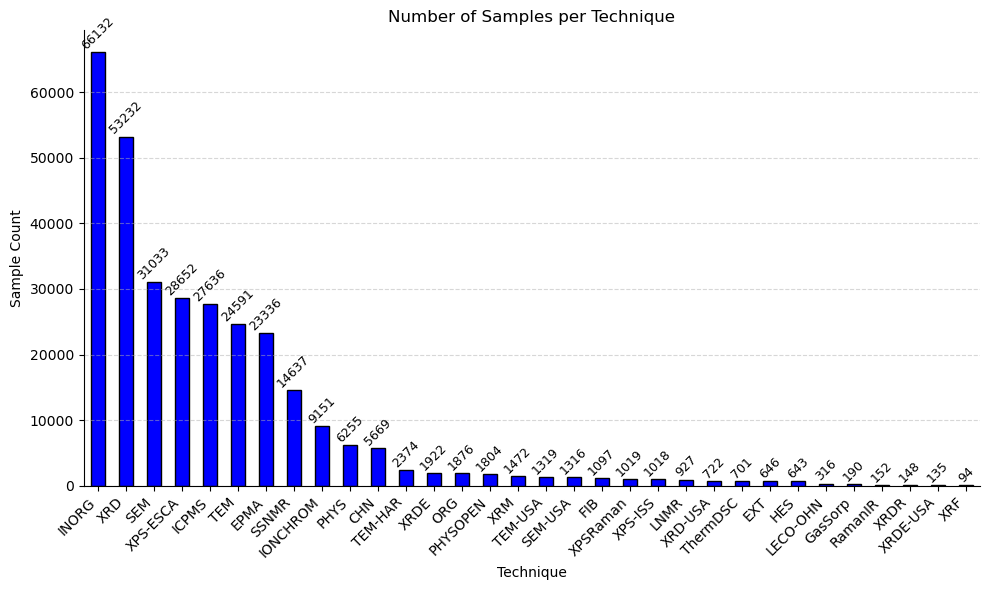

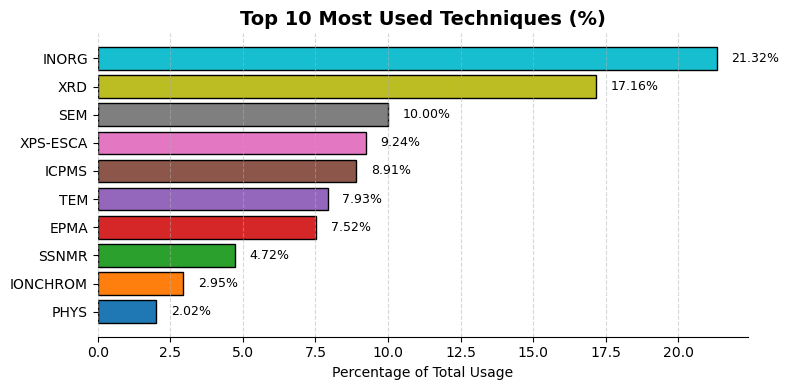

In [94]:
# 2. count occurence of each tecnique

result = "Number of occurrence of each Technique"
display(HTML(f"<p style='font-size:16px;font-weight:bold;'><br>{result}</p>"))


technique_count = df['Technique'].value_counts()  # Count samples per technique-without EXT
tech_most_sample = technique_count.max()            # find the technique with most samples

#---------------------------------------------------------------------
# Plot bar chart and keep the bar container

plt.figure(figsize=(10, 6))

bars = technique_count.plot(kind='bar', color='blue',edgecolor='black')

# Add value labels on top of bars
for index, value in enumerate(technique_count.values):
    plt.text(index, value + 0.5, str(value), ha='center', va='bottom', fontsize=9, rotation = 45)

plt.title('Number of Samples per Technique')
plt.xlabel('Technique')
plt.ylabel('Sample Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Remove the top and right frame (spines)
bars.spines['top'].set_visible(False)
bars.spines['right'].set_visible(False)

plt.show()
#----------------------------------------------------------------
result = "This chart highlights that approximately 10 Techniques are used frequently, with INORG and XRD standing out as the most dominant. "
display(HTML(f"<p style='font-size:18px;font-weight:bold; '>{result}</p>"))
#-------------------------------------------------------------------

# calculate the most frequently used techniques in %
top10_tech = df['Technique'].value_counts(normalize = True).head(10) * 100
top10_tech = top10_tech.round(2)                 # round the result to two decimals

# plot the result in horisontal bars

# Generate a color palette with 10 distinct colors
colors = sns.color_palette('tab10', n_colors=10)  

# Plotting
plt.figure(figsize=(8,4))
bars = plt.barh(top10_tech.index[::-1], top10_tech.values[::-1], color=colors, edgecolor='black')

# Add value labels to bars
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.5, bar.get_y() + bar.get_height()/2, f'{width:.2f}%', va='center', fontsize=9)

# Formatting
plt.title('Top 10 Most Used Techniques (%)', fontsize=14, fontweight='bold')
plt.xlabel('Percentage of Total Usage')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()

# Remove spines
for spine in ['top', 'right', 'left']:
    plt.gca().spines[spine].set_visible(False)

plt.show()


# 3. Calculating Earliest and Latest Submission date for each Technique

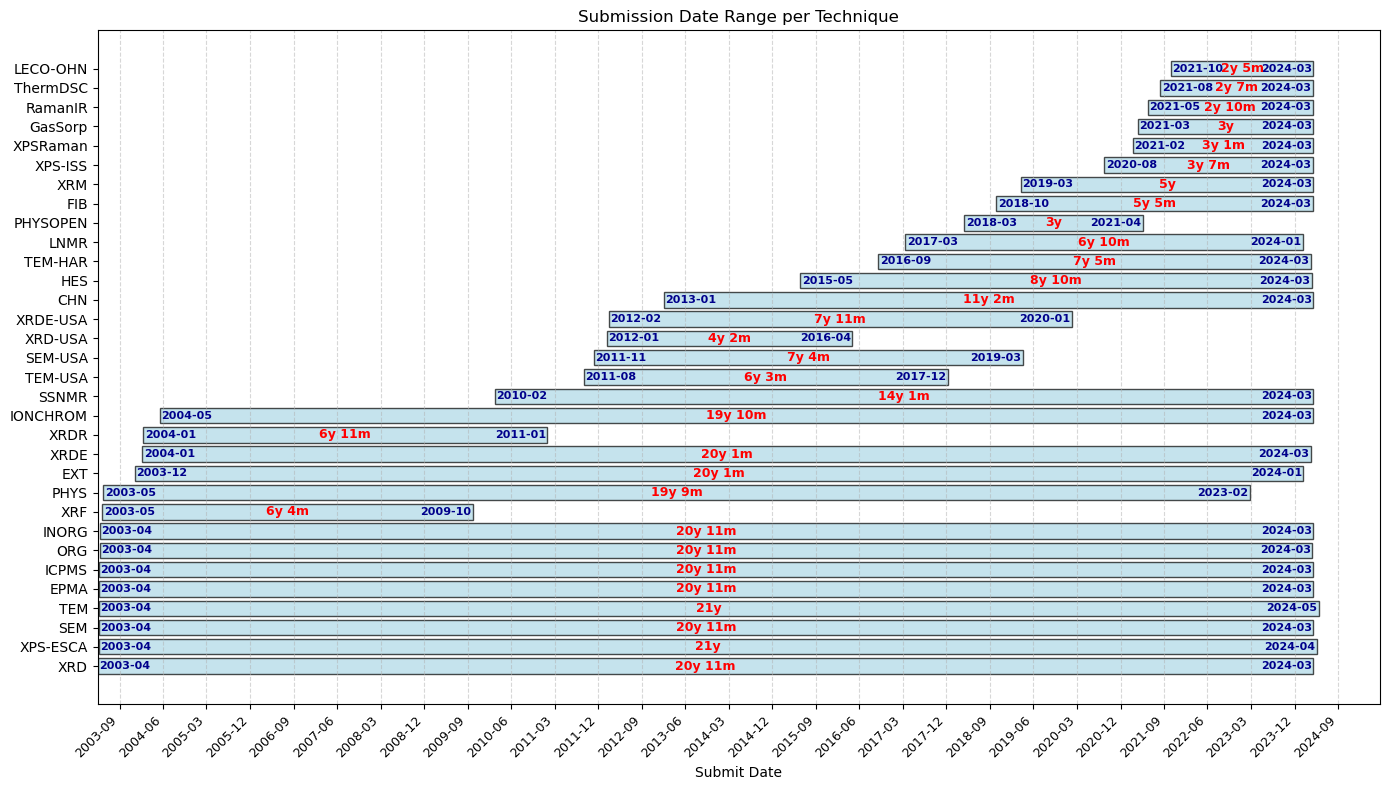

In [96]:
# 3. calculating earliest and latest submission date for each technique

import matplotlib.dates as mdates
from IPython.display import display, HTML

# Converting the column SubmitDate into proper pandas datetime format
df['SubmitDate'] = pd.to_datetime(df['SubmitDate'])

# Group the dates by technique and find the min and max dates
tech_SubDate_df = df.groupby('Technique')['SubmitDate'].agg(['min', 'max']).reset_index()
tech_SubDate_df.columns = ['Technique', 'First Used', 'Last Used']

# Format dates for neat display (remove time component)
tech_SubDate_df['First Used'] = tech_SubDate_df['First Used'].dt.strftime('%Y-%m-%d')
tech_SubDate_df['Last Used'] = tech_SubDate_df['Last Used'].dt.strftime('%Y-%m-%d')

# Display
result = 'Techniques with their Earliest and Latest SubmitDate'
display(HTML(f"<p style='font-size:18px; font-weight:bold;'>{result}</p>"))

#-----------------------------------
# Group by Technique and get date ranges (keep datetime for plotting)
tech_SubDate_df_plot = df.groupby('Technique')['SubmitDate'].agg(['min', 'max']).reset_index()
tech_SubDate_df_plot.columns = ['Technique', 'Earliest SubmitDate', 'Latest SubmitDate']

# Sort techniques by earliest date
tech_SubDate_df_plot = tech_SubDate_df_plot.sort_values(by='Earliest SubmitDate')

# Function to convert days to years and months
def days_to_years_months(days):
    years = days // 365
    months = (days % 365) // 30
    
    if years > 0 and months > 0:
        return f"{years}y {months}m"
    elif years > 0:
        return f"{years}y"
    elif months > 0:
        return f"{months}m"
    else:
        return f"{days}d"

# Create figure
plt.figure(figsize=(14, 8))

# Plot horizontal bars and add labels
for i, row in tech_SubDate_df_plot.iterrows():
    technique = row['Technique']
    start = row['Earliest SubmitDate']
    end = row['Latest SubmitDate']
    duration = (end - start).days
    
    # Plot bar
    plt.barh(
        y=technique,
        width=duration,
        left=start,
        color='lightblue',
        edgecolor='black',
        alpha=0.7
    )
    
    # Format labels as 'YYYY-MM'
    start_label = start.strftime('%Y-%m')
    end_label = end.strftime('%Y-%m')
    
    # Position labels based on bar width
    if duration < 180:  # Less than 6 months - put labels outside
        plt.text(start - pd.Timedelta(days=20), technique, start_label, 
                color='black', fontsize=8, va='center', ha='right')
        plt.text(end + pd.Timedelta(days=20), technique, end_label, 
                color='black', fontsize=8, va='center', ha='left')
    else:  # Longer bars - put labels inside
        plt.text(start + pd.Timedelta(days=10), technique, start_label, 
                color='darkblue', fontsize=8, va='center', ha='left', weight='bold')
        plt.text(end - pd.Timedelta(days=10), technique, end_label, 
                color='darkblue', fontsize=8, va='center', ha='right', weight='bold')
    
    # Add duration in years/months in the middle of the bar
    mid_point = start + pd.Timedelta(days=duration/2)
    if duration > 30:  # Only show duration if bar is wide enough
        duration_label = days_to_years_months(duration)
        plt.text(mid_point, technique, duration_label, 
                color='red', fontsize=9, va='center', ha='center', weight='bold')

# Formatting
plt.xlabel('Submit Date')
plt.title('Submission Date Range per Technique')
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Format x-axis for dates
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=9))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45, ha='right', fontsize=9)

plt.tight_layout()
plt.show()

# print the text- conclusion on botttom of the chart

result = "This task has visualisation named Gantt-style Timeline Chart"
display(HTML(f"<p style='font-size:18px; font-weight:bold;'>{result}</p>"))

# 4. What are the original Techniques? What Techniques came and went? What Techniques were operational into 2024?

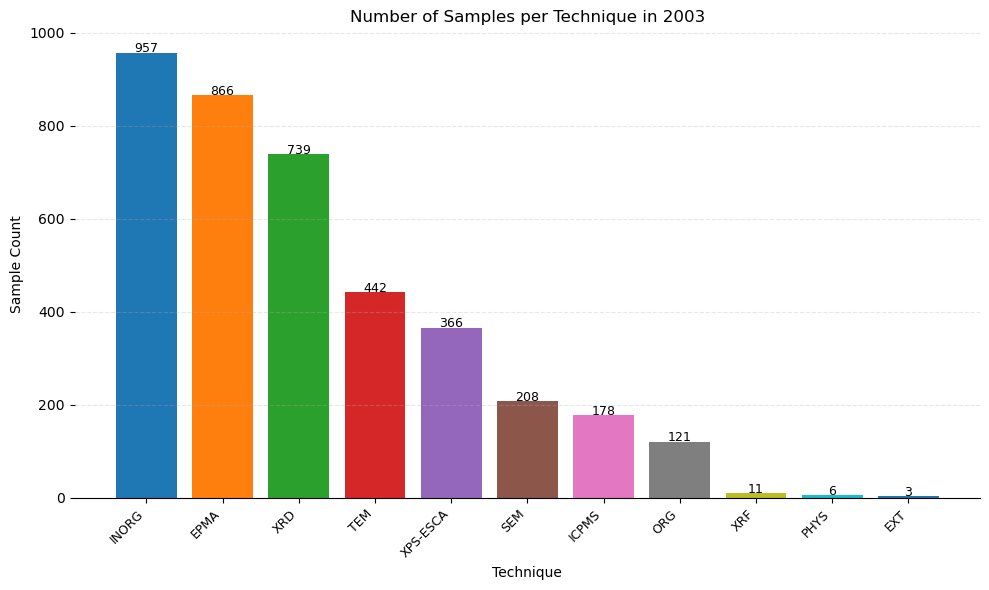

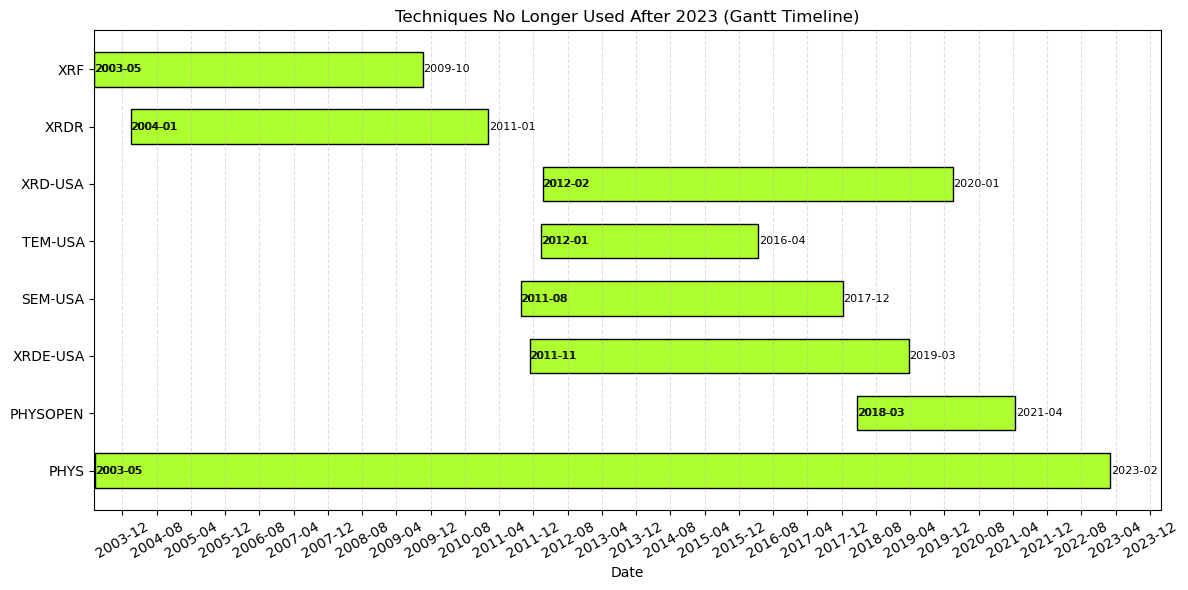

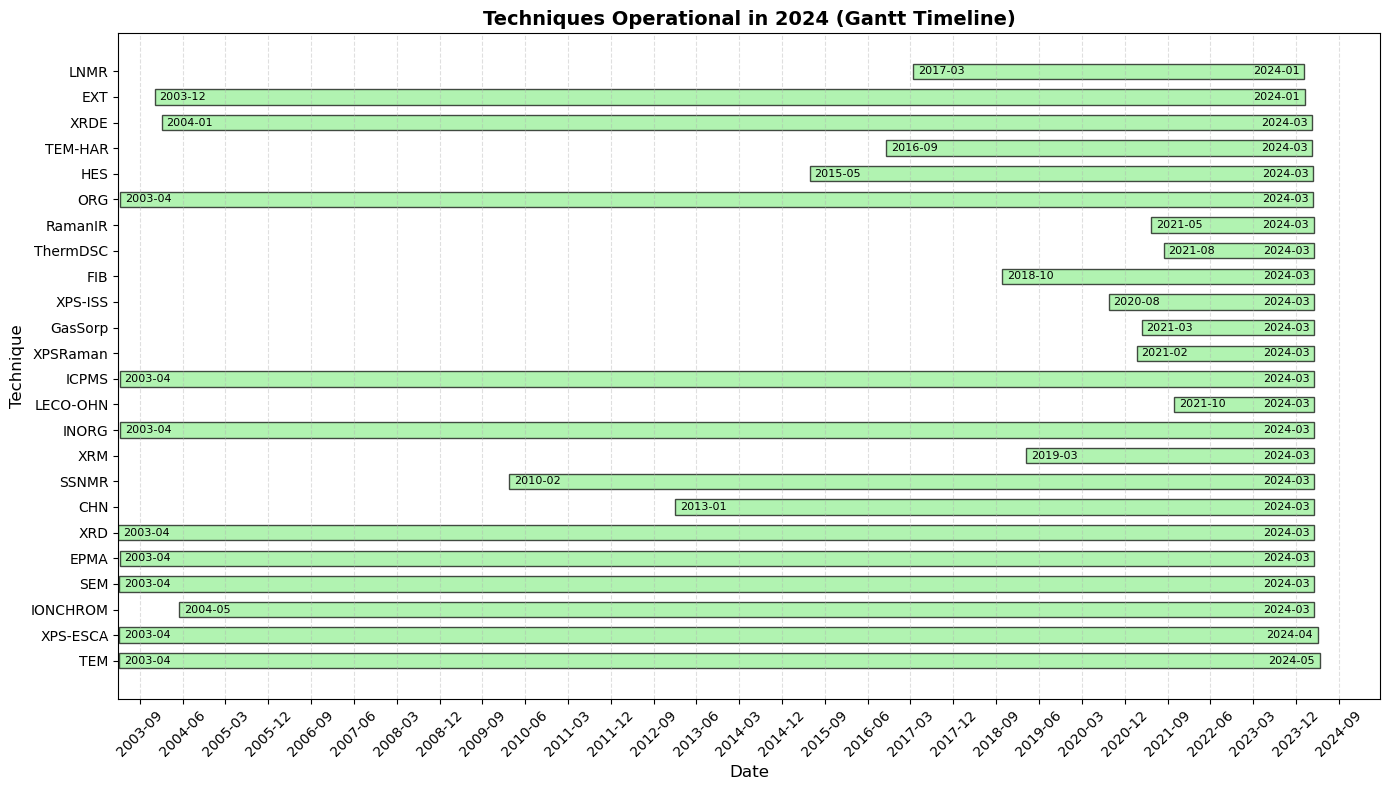

In [98]:
# 4 A. What are the original techniques? What techniques came and went? What techniques were operational into 2024?

earliest_date = df['SubmitDate'].min()          # calculating the earliest date in SubmitDate

# finding the original techniques that was present in 2003, the initial year

df_2003 = df[df['SubmitDate'].dt.year == 2003]  # Filter data for the year 2003

# Count how many times each technique was used
technique_counts_2003 = df_2003['Technique'].value_counts().sort_values(ascending = False)

# printing the first sentence, above the chart
result = "This chart shows the Original Techniques, that was used in 2003 and  No. of samples for each Technique"
display(HTML(f"<p style='font-size:18px; font-weight:bold;'>{result}</p>"))

# Plot, vertical bar chart
colors = sns.color_palette('tab10', n_colors=10)  # (another colors variations could be 'Set3', 'pastel')

plt.figure(figsize=(10, 6))
bars = plt.bar(technique_counts_2003.index, technique_counts_2003.values, color=colors)

# Add value labels on top of each bar

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.5, str(int(height)), ha='center', fontsize=9)

# Title and labels
plt.title('Number of Samples per Technique in 2003')
plt.xlabel('Technique')
plt.ylabel('Sample Count')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Remove all spines
plt.gca().spines['left'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)


# Remove vertical grid lines
plt.grid(axis='x', visible=False)

plt.show()
#---------------------------------------------------------------------------------------------------

# 4 B. Techniques that were used only during a specific time period, i.e., no longer used by the last date

tech_range = df.groupby('Technique')['SubmitDate'].agg(['min','max'])   # Get the time range for each technique
cutoff_date = pd.Timestamp('2024-01-01')                                # latest date in Submit Date
tech_used = tech_range[tech_range['max'] < cutoff_date].reset_index()   # Filter techniques no longer used after cutoff date
tech_used = tech_used.sort_values(by = 'max', ascending = False)        # sort by last used date
tech_used.columns = ['Technique', 'First Used', 'Last Used']            # renaming the columns

# Convert datetime columns to string format without time
tech_used['First Used'] = pd.to_datetime(tech_used['First Used']).dt.strftime('%Y-%m-%d')
tech_used['Last Used'] = pd.to_datetime(tech_used['Last Used']).dt.strftime('%Y-%m-%d')

# Print the text bellow the first chart
result = "The table below shows all the Techniques that are no longer in use — 8 in total, i.e., Techniques that haven't been used in 2024."
display(HTML(f"<p style='font-size:18px; font-weight:bold;'>{result}</p>"))


# Make sure datetime columns are datetime
tech_used['First Used'] = pd.to_datetime(tech_used['First Used'])
tech_used['Last Used'] = pd.to_datetime(tech_used['Last Used'])


# Sort for visual clarity
tech_used = tech_used.sort_values('Last Used', ascending = False)

plt.figure(figsize=(12, 6))

for i, row in tech_used.iterrows():
    start = row['First Used']
    end = row['Last Used']
    duration = (end - start).days

    # Plot the bar
    plt.barh(y=i, width=duration, left=start, height=0.6, color='greenyellow', edgecolor='black')

    # Format labels as 'yyyy-mm'
    start_label = start.strftime('%Y-%m')
    end_label = end.strftime('%Y-%m')

    # Place start label to the left
    plt.text(start - pd.Timedelta(days=3), i, start_label,
             va='center', ha='left', fontsize=8)

    # Place end label to the right
    plt.text(end + pd.Timedelta(days=3), i, end_label,
            va='center', ha='left', fontsize=8)
    if duration > 90:
        plt.text(start + pd.Timedelta(days=5), i, start_label, color='black', fontsize=8, va='center')
    else:
        plt.text(start - pd.Timedelta(days=3), i, start_label, fontsize=8, va='center', ha='right')


# Set y-ticks as technique names
plt.yticks(ticks=range(len(tech_used)), labels=tech_used['Technique'])

# Formatting x-axis as yyyy-mm
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=8))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=30)

plt.xlabel('Date')
plt.title('Techniques No Longer Used After 2023 (Gantt Timeline)')
plt.tight_layout()
plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.show()

# 4.C Techniques operational in 2024

# Filter techniques operational in 2024 with min and max dates
tech_2024_df = tech_range[tech_range['max'] >= '2024-01-01'].reset_index()
tech_2024_df.columns = ['Technique', 'First Used', 'Last Used']

# Keep datetime format for plotting (don't convert to string yet)
tech_2024_df_plot = tech_2024_df.copy()

# Convert to datetime if they aren't already
tech_2024_df_plot['First Used'] = pd.to_datetime(tech_2024_df_plot['First Used'])
tech_2024_df_plot['Last Used'] = pd.to_datetime(tech_2024_df_plot['Last Used'])

# Sort by 'Last Used' (descending) for plotting
tech_2024_df_plot = tech_2024_df_plot.sort_values(by='Last Used', ascending=False).reset_index(drop=True)

# Format dates for display table (after creating plot dataframe)
tech_2024_df['First Used'] = pd.to_datetime(tech_2024_df['First Used']).dt.strftime('%Y-%m-%d')
tech_2024_df['Last Used'] = pd.to_datetime(tech_2024_df['Last Used']).dt.strftime('%Y-%m-%d')

# Print text above the chart
result = "Techniques Operational in 2024:"
display(HTML(f"<p style='font-size:18px; font-weight:bold;'>{result}</p>"))

# Plot gantt chart
plt.figure(figsize=(14, 8))

for i, row in tech_2024_df_plot.iterrows():
    start = row['First Used']
    end = row['Last Used']
    duration = (end - start).days
    
    # Draw the horizontal bar
    plt.barh(y=i, width=duration, left=start, height=0.6, 
             color='lightgreen', edgecolor='black', alpha=0.7)
    
    # Format labels as 'YYYY-MM'
    start_label = start.strftime('%Y-%m')
    end_label = end.strftime('%Y-%m')
    
    # Show labels (adjust positioning based on bar width)
    if duration > 365:  # If technique used for more than a year
        # Put labels inside the bar
        plt.text(start + pd.Timedelta(days=30), i, start_label, 
                color='black', fontsize=8, va='center', ha='left')
        plt.text(end - pd.Timedelta(days=30), i, end_label, 
                color='black', fontsize=8, va='center', ha='right')
    else:
        # Put labels outside the bar for shorter durations
        plt.text(start - pd.Timedelta(days=15), i, start_label, 
                color='black', fontsize=8, va='center', ha='right')
        plt.text(end + pd.Timedelta(days=15), i, end_label, 
                color='black', fontsize=8, va='center', ha='left')

# Set y-ticks as technique names
plt.yticks(ticks=range(len(tech_2024_df_plot)), labels=tech_2024_df_plot['Technique'])

# Format x-axis as YYYY-MM
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=9))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)

plt.xlabel('Date', fontsize=12)
plt.ylabel('Technique', fontsize=12)
plt.title('Techniques Operational in 2024 (Gantt Timeline)', fontsize=14, fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

# print the last text, it is short conclusion about this task

result = "The chart indicates that 24 techniques are still in use"
display(HTML(f"<p style='font-size:18px; font-weight:bold;'>{result}</p>"))


# 5.Techniques that had the most samples per "Operational" Time 

╒═════════════╤════════════╤════════════╤════════════════╤════════════════════╤═══════════════════╕
│ Technique   │ Min_date   │ Max_date   │   Sample_Count │   Operational_days │   Samples_per_day │
╞═════════════╪════════════╪════════════╪════════════════╪════════════════════╪═══════════════════╡
│ INORG       │ 2003-04-30 │ 2024-03-28 │          66132 │               7638 │         8.65829   │
├─────────────┼────────────┼────────────┼────────────────┼────────────────────┼───────────────────┤
│ XRD         │ 2003-04-16 │ 2024-03-28 │          53232 │               7653 │         6.9557    │
├─────────────┼────────────┼────────────┼────────────────┼────────────────────┼───────────────────┤
│ SEM         │ 2003-04-23 │ 2024-03-28 │          31033 │               7646 │         4.05872   │
├─────────────┼────────────┼────────────┼────────────────┼────────────────────┼───────────────────┤
│ XPS-ESCA    │ 2003-04-22 │ 2024-04-18 │          28652 │               7667 │         3.73705   │


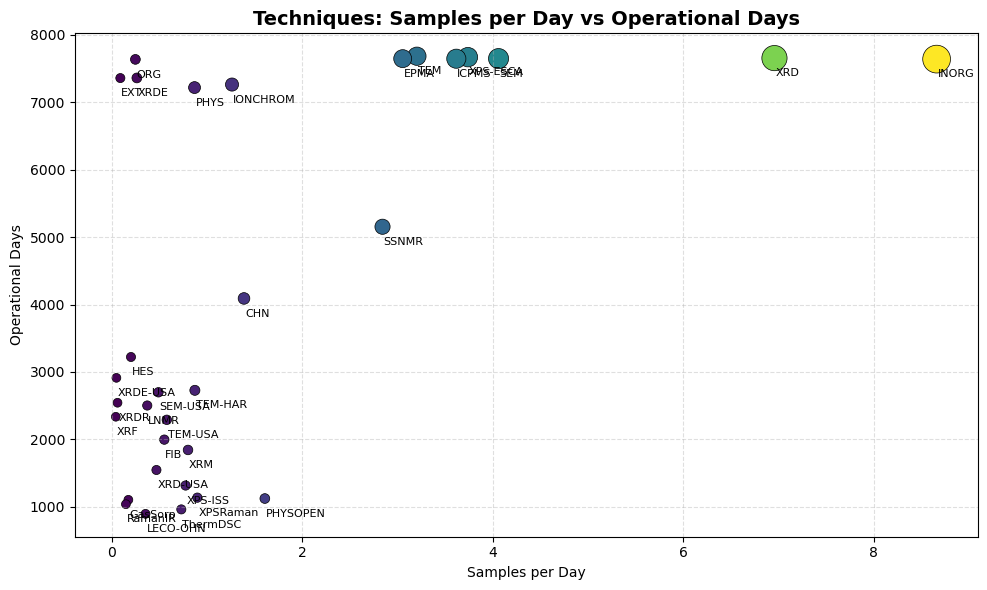

In [100]:
# 5.Techniques that had the most samples per "operational" time 
    
# Group by technique and calculate date range + sample count in one step
technique_stats = df.groupby('Technique')['SubmitDate'].agg([ ('Min_date', 'min'),('Max_date', 'max'), ('Sample_Count', 'count')]).reset_index()
    
# Calculate operational days and samples per day
technique_stats['Operational_days'] = (technique_stats['Max_date'] - technique_stats['Min_date']).dt.days + 1
technique_stats['Samples_per_day'] = (technique_stats['Sample_Count'] / technique_stats['Operational_days'])
    
technique_analysis = technique_stats.sort_values('Samples_per_day', ascending=False)

# Format dates for more readable display, without time
technique_analysis['Min_date'] = technique_analysis['Min_date'].dt.strftime('%Y-%m-%d')
technique_analysis['Max_date'] = technique_analysis['Max_date'].dt.strftime('%Y-%m-%d')

# print heading and table
result =  "Techniques with most samples per 'Operational' Time:"
display(HTML(f"<p style='font-size:18px; font-weight:bold;'>{result}</p>"))

print(tabulate(technique_analysis, headers='keys', tablefmt='fancy_grid', showindex=False))
#------------------------------------------------------------------------------------------
# plot version, with scatterplot seaborn

# Limit to top N for clarity (optional)
top_techniques = technique_analysis.sort_values('Sample_Count', ascending=False).head(50)

# Scale bubble sizes
size_scale = 500
bubble_sizes = top_techniques['Sample_Count'] / top_techniques['Sample_Count'].max() * size_scale

plt.figure(figsize=(10, 6))

# Create scatter plot
scatter = sns.scatterplot(
    data=top_techniques,
    x='Samples_per_day',
    y='Operational_days',
    size=bubble_sizes,
    hue='Samples_per_day',
    sizes=(40, 400),
    palette='viridis',
    edgecolor='black',
    legend=False
)

# Add technique labels to bubbles
for _, row in top_techniques.iterrows():
    plt.text(
        row['Samples_per_day'] + 0.01,        # x-position
        row['Operational_days'] - 150,        # y-position
        row['Technique'],
        fontsize=8,
        va='top'                             # Align text from the top
    )

# Customize plot
plt.title("Techniques: Samples per Day vs Operational Days", fontsize=14, fontweight='bold')
plt.xlabel("Samples per Day")
plt.ylabel("Operational Days")
plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

# print the last statement, a short conclusion about this task

result = "INORG is the most-used Technique per day, followed by XRD and SEM — all in use since 2003"
display(HTML(f"<p style='font-size:18px; font-weight:bold;'>{result}</p>"))


# 6.Calculate the Analysts that handled the most samples

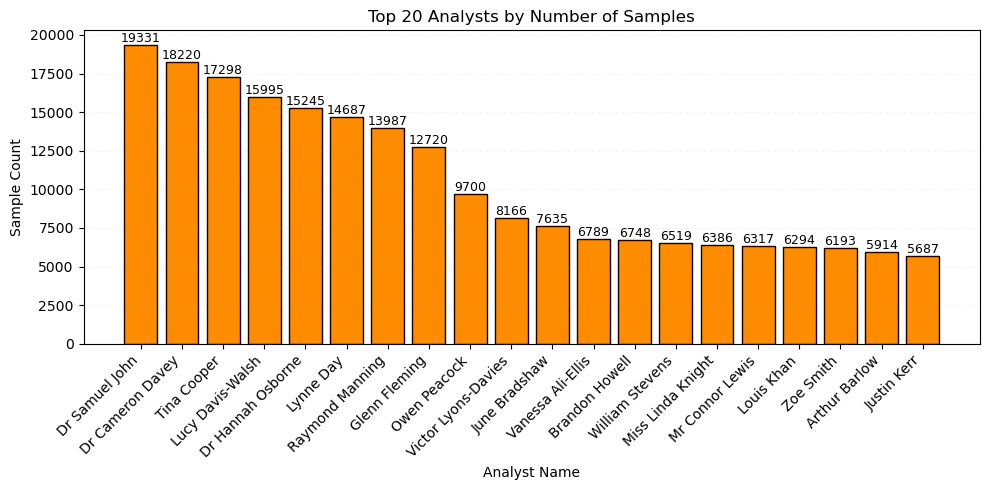

In [102]:
# 6.calculate the analysts that handled the most samples

# printing the first heading
result = "Analysts that handled the most samples"
display(HTML(f"<p style='font-size:18px; font-weight:bold;'>{result}</p>"))

analyst_name = df['AnalystName'].value_counts().rename_axis('AnalystName').reset_index(name ='SampleCount').head(20)

# Top 20 analysts by number of samples
top_analysts = df['AnalystName'].value_counts().head(20)

# creating the plot, vertical bar chart

plt.figure(figsize=(10, 5))

# Draw bars
bars = plt.bar(range(len(top_analysts)), top_analysts.values, color='darkorange', edgecolor='black')

# Add value labels on top of each bar
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 1, str(height), 
             ha='center', va='bottom', fontsize=9)

# Set custom x-tick labels
plt.xticks(ticks=range(len(top_analysts)), labels=top_analysts.index, rotation=45, ha='right')

plt.title('Top 20 Analysts by Number of Samples')
plt.xlabel('Analyst Name')
plt.ylabel('Sample Count')
plt.grid(axis='y', linestyle='--', alpha=0.1)
plt.tight_layout()
plt.show()

# I want to present the % of samples that first 20 analysts had made out of total samples

# Total number of samples (all analysts)
total_samples = len(df)

# Number of samples handled by the top 20 analysts
top_20_samples = df['AnalystName'].value_counts().head(20).sum()

# Calculate percentage
percentage = (top_20_samples / total_samples) * 100

# Display the result= conclusion bellow thw chart, for this task
result = f"Top 20 Analysts handled {top_20_samples} out of {total_samples} samples ({percentage:.2f}%)"
display(HTML(f"<p style='font-size:18px; font-weight:bold'>{result}</p>"))



# 7.Can you tell what Techniques the Analysts worked with? 

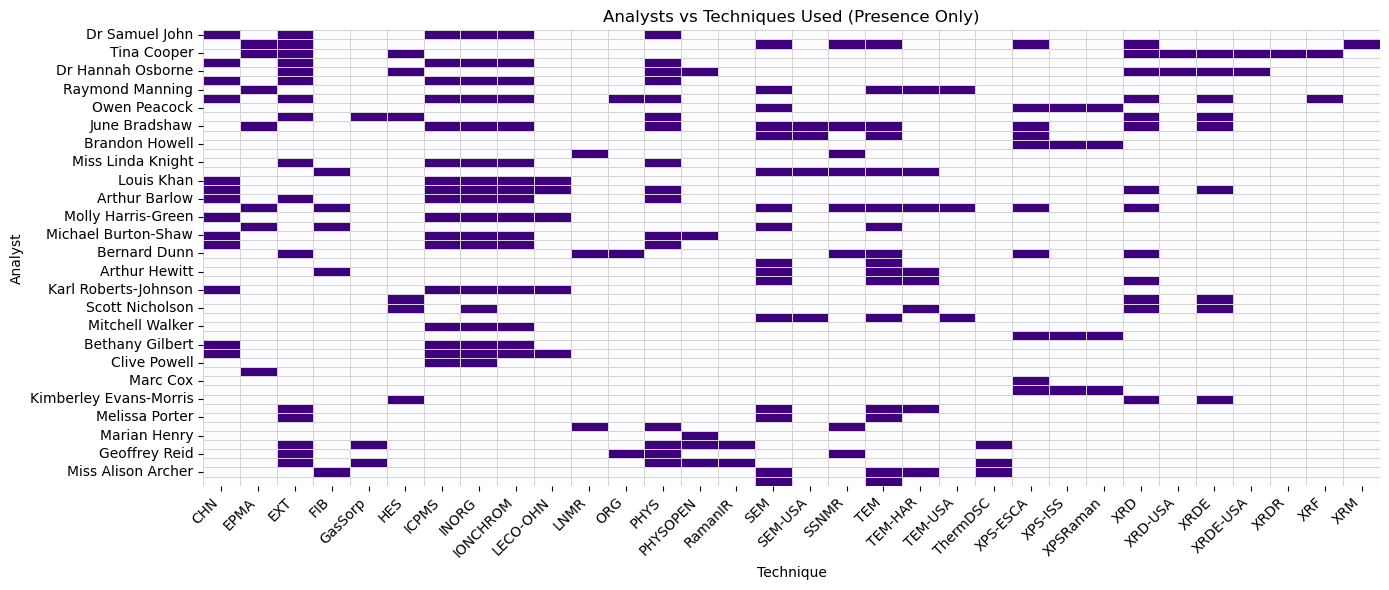

In [104]:
# 7.Can you tell what techniques the analysts worked with?

# grouping the Analyst Name data and found the unique Technique each Analyst have worked
analyst_technique = df.groupby('AnalystName')['Technique'].unique().reset_index()

# Convert arrays to comma-separated strings, meaningt Take a list, remove duplicates, sort alphabetically, and join into one comma-separated string
analyst_technique['Technique'] = analyst_technique['Technique'].apply(lambda x: ', '.join(sorted(set(x))))

#print the Heading in html style
result = "Analyst Name and the Technique they worked with, presented in Matrix chart"
display(HTML(f"<p style='font-size:16px; font-weight:bold; '>{result}</p>"))
#------------------------------

# Create binary matrix: 1 if analyst used technique, else 0
matrix = df.groupby(['AnalystName', 'Technique']).size().unstack(fill_value=0)
matrix = matrix.clip(upper=1)  # convert counts to 1s

# Keep top 50 analysts
top_analysts = df['AnalystName'].value_counts().head(50).index
matrix = matrix.loc[top_analysts]

plt.figure(figsize=(14, 6))
sns.heatmap(matrix, cmap='Purples', cbar=False, linewidths=0.5, linecolor='lightgray')
plt.title("Analysts vs Techniques Used (Presence Only)")
plt.xlabel("Technique")
plt.ylabel("Analyst")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


# print the short conclusion
result = "Most of the Analysts use more that one Techniques"
display(HTML(f"<p style='font-size:18px; font-weight:bold; '>{result}</p>"))


# 8.Which Submitters sent in the most requests?

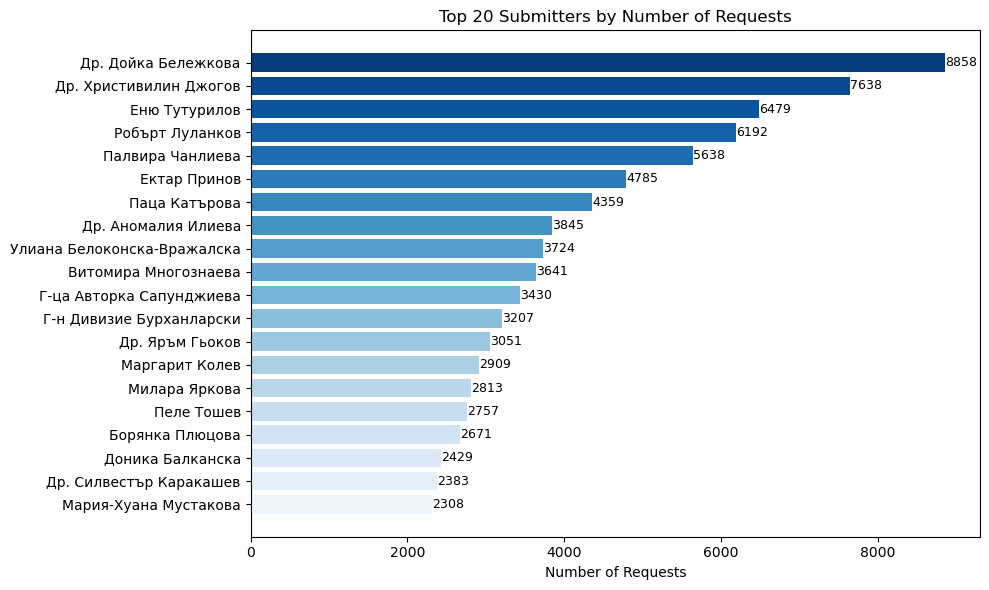

In [106]:
# 8.Which submitters sent in the most requests?

submitter_count = df['SubmitterName'].value_counts().rename_axis('SubmitterName').reset_index(name = 'Count').head(20)

#print the heading in html version
result = 'Name of Submitter and the Number of Requests Submitted'
display(HTML(f"<p style='font-size:16px; font-weight:bold; '>{result}</p>"))


# Sort so that highest is on top
submitter_count = submitter_count.sort_values(by='Count', ascending=True)

# Plot
plt.figure(figsize=(10, 6))
bars = plt.barh(submitter_count['SubmitterName'], submitter_count['Count'], color=sns.color_palette("Blues", n_colors=20))

# Add value labels to the end of bars
for bar in bars:
    width = bar.get_width()
    plt.text(width + 1, bar.get_y() + bar.get_height()/2,
             f'{int(width)}', va='center', fontsize=9)

plt.xlabel("Number of Requests")
plt.title("Top 20 Submitters by Number of Requests")
plt.tight_layout()

plt.show()

result = "The Submitter who submitted the most requests is Др. Дойка Бележкова with 8858 requests."
display(HTML(f"<p style='font-size:16px; font-weight:bold; '>{result}</p>"))

# calculating the Top 20 Submitters request as % of total request

total_requests = len(df)
top_20_submitters = df['SubmitterName'].value_counts().head(20).sum()
top_20_submitters_ratio = top_20_submitters/total_requests * 100

result = f"Top 20 Submitters handled {top_20_submitters} out of {total_requests} requests ({top_20_submitters_ratio:.2f}%)"
display(HTML(f"<p style='font-size:16px; font-weight:bold'>{result}</p>"))

# 9.  Did some Submitters use certain Techniques more often than others?

In [108]:
# 9.  Did some submitters use certain techniques more often than others?
# We can find this by:
# Counting how many times each SubmitterName–Technique pair appears
# Identifying the most-used technique per submitter.
# Count how many times each Submitter used each technique

submitter_tech_count = df.groupby(['SubmitterName', 'Technique']).size().reset_index(name='Counts')

#  Find total requests per Submitter
submitter_total = submitter_tech_count.groupby('SubmitterName')['Counts'].sum().reset_index(name='Total')

# Find max count technique(s) per Submitter
max_counts = submitter_tech_count.groupby('SubmitterName')['Counts'].transform('max')
favourite_tech = submitter_tech_count[submitter_tech_count['Counts'] == max_counts]

# Merge total to get percentage
favourite_tech = favourite_tech.merge(submitter_total, on='SubmitterName')
favourite_tech['Favourite %'] = favourite_tech['Counts'] / favourite_tech['Total'] * 100

# Aggregate multiple favourites
favourite_per_submitter = favourite_tech.groupby('SubmitterName').agg({
    'Technique': lambda x: ', '.join(sorted(set(x))),
    'Favourite %': 'mean'
}).reset_index()

# Round AFTER aggregating 
favourite_per_submitter['Favourite %'] = favourite_per_submitter['Favourite %'].round(2).astype(str) + '%'

# Get all techniques used per submitter
all_technique = df.groupby('SubmitterName')['Technique'].apply(lambda x: ', '.join(sorted(set(x)))).reset_index(name='All Techniques')

# Merge everything together
submitter_technique = all_technique.merge(favourite_per_submitter, on='SubmitterName').head(20)

# rename columns
submitter_technique.columns = ['Submitter Name', 'All Techniques', 'Favourite Technique(s)', 'Favourite %']

# Display styled table without index 
styled_table = submitter_technique.style.set_table_attributes(
    'style="border-collapse:collapse; font-size:13px;"'
).set_properties(**{
    'border': '1px solid lightgray',
    'padding': '6px',
    'font-family': 'Arial, sans-serif'
}).hide(axis='index')  # FIXED: removed undefined column_styles

# Heading
result = "Submitter's Name, Techniques Used, Favourite Technique(s), and Usage %"
display(HTML(f"<p style='font-size:16px; font-weight:bold;'>{result}</p>"))

# Display
display(styled_table)


Submitter Name,All Techniques,Favourite Technique(s),Favourite %
Авгия Сланинкова,"EPMA, HES, INORG, SSNMR, XPS-ESCA, XRD",INORG,47.33%
Авел Вакрилов,"EPMA, PHYS, SEM, XPS-ESCA, XPS-ISS, XPSRaman, XRD",SEM,25.49%
Аверно Цветков,"EPMA, ICPMS, INORG, SEM",INORG,45.0%
Аврели Пулев,"EPMA, ICPMS, INORG, PHYS, SEM, XPS-ESCA",SEM,40.43%
Авторка Първанова,"EPMA, INORG, SEM, TEM, ThermDSC, XPS-ESCA, XPSRaman",XPS-ESCA,58.24%
Агнеш Рангелов,"CHN, ICPMS, INORG, IONCHROM, LECO-OHN, TEM, TEM-HAR, ThermDSC, XPS-ESCA, XPSRaman, XRD",XPS-ESCA,25.94%
Агнеш Рошльов,"EPMA, PHYS, RamanIR, SSNMR, TEM-HAR, XPS-ESCA, XPS-ISS, XRD, XRDE",XRD,21.53%
Агъци Младенова,"PHYS, SEM, SSNMR, XPS-ESCA, XRD, XRM","PHYS, SSNMR",30.77%
Адам Колипатков,INORG,INORG,100.0%
Адам Площаков,SEM,SEM,100.0%


### This is additional analyse, I want to calculate average turnaround time per Technique,
### to see whether turnaround time is a key for frequent use of certain Technique

Technique,Sample Count,Avg Days,Median Days,Std Dev,Min Days,Max Days,CV %
XRDR,73,762.700000,753.000000,720.070000,1.000000,2782.000000,94.410000
GasSorp,17,275.470000,419.000000,168.390000,1.000000,419.000000,61.130000
HES,488,259.130000,168.000000,245.540000,1.000000,1211.000000,94.760000
ORG,609,167.100000,17.000000,537.070000,1.000000,2752.000000,321.410000
XRDE,1574,107.280000,62.000000,155.540000,1.000000,1661.000000,144.990000
TEM-HAR,1016,101.190000,52.000000,132.980000,1.000000,910.000000,131.420000
RamanIR,14,92.000000,3.000000,127.990000,2.000000,281.000000,139.120000
XRDE-USA,124,73.790000,55.000000,73.080000,1.000000,302.000000,99.040000
SSNMR,7596,66.360000,44.000000,83.330000,1.000000,805.000000,125.570000
EXT,185,64.380000,17.000000,105.350000,1.000000,443.000000,163.640000


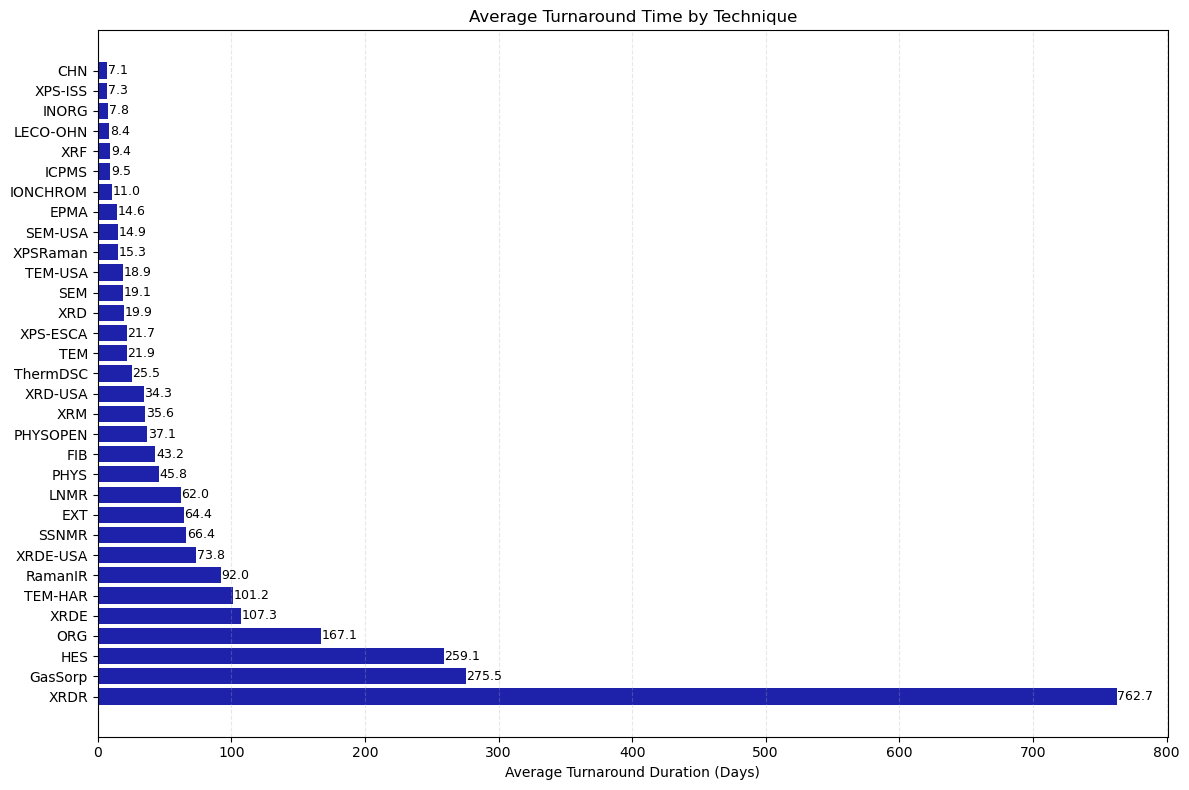


- **CV** = Coefficient of Variation
- **Lower CV%** indicates more consistent analysis times  
- **Higher CV%** indicates more variable analysis times  
- **CV% < 20%** is generally considered low variability  
- **CV% > 50%** indicates high variability


In [110]:
# this is additional analyse=I want to calculate average turnaround time per technique,
#to see whether turnaround time is a key for frequent use of certain Technique

from IPython.display import Markdown, display

# Calculate analysis duration in days (turnaround time)
df['TurnaroundDays'] = (df['EndDate'] - df['AcceptDate']).dt.days

# Only filter out negative turnaround days (data errors)
df = df[(df['TurnaroundDays'] > 0) | (df['TurnaroundDays'].isna())]

# Calculate analysis duration in days for each sample
df['Analysis_Duration_Days'] = (df['EndDate'] - df['AcceptDate']).dt.days

# Calculate statistics per technique
technique_time_stats = df.groupby('Technique')['Analysis_Duration_Days'].agg([
    'count',    # Number of samples
    'mean',     # Average duration
    'median',   # Median duration
    'std',      # Standard deviation
    'min',      # Minimum duration
    'max'       # Maximum duration
]).round(2).reset_index()

# Rename columns for clarity
technique_time_stats.columns = ['Technique', 'Sample Count', 'Avg Days', 'Median Days', 
                                'Std Dev', 'Min Days', 'Max Days']

# Calculate coefficient of variation (CV) to measure consistency

technique_time_stats['CV %'] = ((technique_time_stats['Std Dev'] / technique_time_stats['Avg Days']) * 100).round(2)

# Sort by average duration
technique_time_stats_sorted = technique_time_stats.sort_values('Avg Days', ascending=False)

# Display results
result = "Average Turnaround Time per Technique"
display(HTML(f"<p style='font-size:16px; font-weight:bold;'>{result}</p>"))

# Style and display the table
styled_table = technique_time_stats_sorted.style.set_table_attributes(
    'style="border-collapse:collapse; font-size:13px;"'
).set_properties(**{
    'border': '1px solid lightgray',
    'padding': '6px',
    'font-family': 'Arial, sans-serif'
}).hide(axis='index')

display(styled_table)

# Create visualization
plt.figure(figsize=(12, 8))
'''bars = plt.barh(technique_time_stats_sorted['Technique'], 
                technique_time_stats_sorted['Avg Days'],
                color=plt.cm.plasma(np.linspace(0.3, 0.9, len(technique_time_stats_sorted))))'''

bars = plt.barh(technique_time_stats_sorted['Technique'], 
                technique_time_stats_sorted['Avg Days'],
                color='#1e22aa')  # Your dark blue color

# Add value labels
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.5, bar.get_y() + bar.get_height()/2, 
             f'{width:.1f}', va='center', fontsize=9)

plt.xlabel('Average Turnaround Duration (Days)')
plt.title('Average Turnaround Time by Technique')
plt.tight_layout()
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.show()

# Analysis interpretation heading
result = "Interpretation:"
display(HTML(f"<p style='font-size:16px; font-weight:bold;'>{result}</p>"))

# Markdown interpretation content
result = """
- **CV** = Coefficient of Variation
- **Lower CV%** indicates more consistent analysis times  
- **Higher CV%** indicates more variable analysis times  
- **CV% < 20%** is generally considered low variability  
- **CV% > 50%** indicates high variability
"""

display(Markdown(result))

# print the short conclusion
result = """From the table above, it is clear that each Technique exhibits significant variance in turnaround time (CV% > 50).
<br> Analysis indicates that the most commonly used Techniques are not selected primarily because of shorter processing times.
"""
display(HTML(f"<p style='font-size:16px; font-weight:bold;'>{result}</p>"))


# "XRDR Technique 🔍 Additional Analysis(Technique with the longest average Turnaround time)"

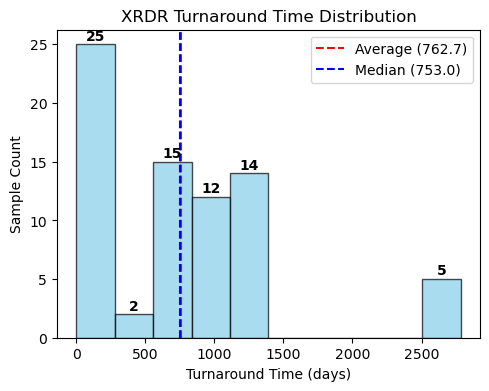

In [114]:
# Simple XRDR Analysis

# Filter data for XRDR technique only
xrdr_data = df[df['Technique'] == 'XRDR'].copy()

# Calculate processing time if not exists
if 'turnaround_time' not in xrdr_data.columns:
    xrdr_data['AcceptDate'] = pd.to_datetime(xrdr_data['AcceptDate'], errors='coerce')
    xrdr_data['EndDate'] = pd.to_datetime(xrdr_data['EndDate'], errors='coerce')
    xrdr_data['turnaround_time'] = (xrdr_data['EndDate'] - xrdr_data['AcceptDate']).dt.days

# Remove invalid data
xrdr_clean = xrdr_data.dropna(subset=['turnaround_time']).copy()
xrdr_clean = xrdr_clean[xrdr_clean['turnaround_time'] >= 0]

# Basic statistics in HTML
stats_html = f"""
<div style='background-color:#f5f5f5; padding:15px; border-left:4px solid #2196F3; margin:15px 0;'>
<h3 style='color:#1976D2; margin-top:0;'>XRDR Technique Analysis</h3>
<p style='color:#666; margin-bottom:10px;'><strong>{len(xrdr_clean)} samples analyzed | Active period: 2004-2011</strong></p>
<p><strong>Average processing time:</strong> {xrdr_clean['turnaround_time'].mean():.1f} days</p>
<p><strong>Median processing time:</strong> {xrdr_clean['turnaround_time'].median():.1f} days</p>
<p><strong>Minimum:</strong> {xrdr_clean['turnaround_time'].min():.0f} days</p>
<p><strong>Maximum:</strong> {xrdr_clean['turnaround_time'].max():.0f} days</p>
</div>
"""
display(HTML(stats_html))


# Simple visualization
plt.figure(figsize=(12, 4))

# Histogram
plt.subplot(1, 2, 1)
n, bins, patches = plt.hist(xrdr_clean['turnaround_time'], bins=10, color='skyblue', alpha=0.7, edgecolor='black')

# Add values on top of bars
for i in range(len(n)):
    if n[i] > 0:  # Only add text if bar has height
        plt.text(bins[i] + (bins[i+1] - bins[i])/2, n[i] + 0.1, f'{int(n[i])}', 
                ha='center', va='bottom', fontweight='bold')

# Add average and median lines with values
mean_val = xrdr_clean['turnaround_time'].mean()
median_val = xrdr_clean['turnaround_time'].median()

plt.axvline(mean_val, color='red', linestyle='--', label=f'Average ({mean_val:.1f})')
plt.axvline(median_val, color='blue', linestyle='--', label=f'Median ({median_val:.1f})')

plt.xlabel('Turnaround Time (days)')
plt.ylabel('Sample Count')
plt.title('XRDR Turnaround Time Distribution')
plt.legend()

# Outlier analysis in HTML

# Outlier threshold calculation
Q1 = xrdr_clean['turnaround_time'].quantile(0.25)
Q3 = xrdr_clean['turnaround_time'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

slow_samples = xrdr_clean[xrdr_clean['turnaround_time'] > upper_bound]

outlier_html = f"""
<div style='background-color:#fff3e0; padding:15px; border-left:4px solid #ff9800; margin:15px 0;'>
<h3 style='color:#f57c00; margin-top:0;'>⚠️ Slow Samples Analysis</h3>
<p><strong>Slow samples (>{upper_bound:.0f} days):</strong> {len(slow_samples)} samples</p>
"""

if len(slow_samples) > 0:
    outlier_html += "<p><strong>Top 3 slowest samples:</strong></p><ul>"
    top_slow = slow_samples.nlargest(3, 'turnaround_time')
    for i, (_, row) in enumerate(top_slow.iterrows(), 1):
        outlier_html += f"<li>{row['RequestNumber']}: {row['turnaround_time']:.0f} days</li>"
    outlier_html += "</ul>"

outlier_html += "</div>"
display(HTML(outlier_html))

# final statement
result = "The XRDR Technique has 5 samples that deviate significantly from the average turnaround time(Slow Samples)."
display(HTML(f"<p style='font-size:18px; color:#333;'><b>{result}</b></p>"))


# 10.Which Submitters used the largest variety of Techniques?

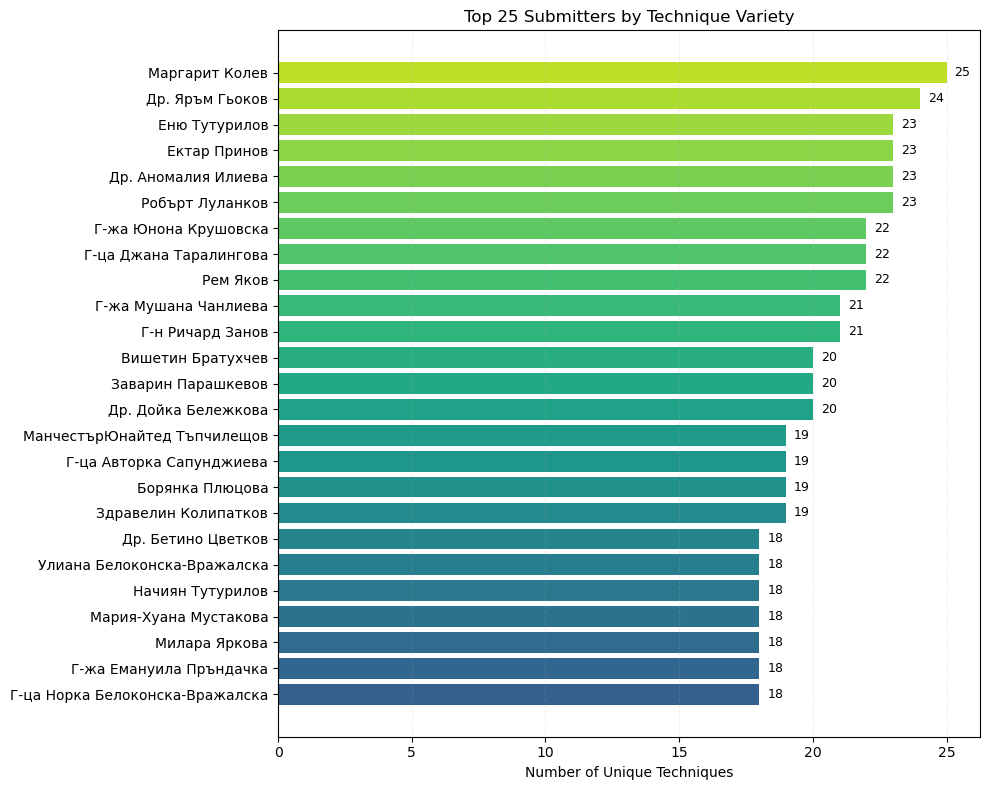

In [21]:
# 10.Which submitters used the largest variety of techniques?

# count unique techniques each submitter use
submitter_all_unique = df.groupby('SubmitterName')['Technique'].nunique().reset_index(name = 'Number of Techniques')

# sort on decs order
submitter_all_unique_sorted = submitter_all_unique.sort_values(by ='Number of Techniques', ascending = False).head(25)[::-1]

#print the heding in html style
result = "Submitters that used largest variety of Techniques"
display(HTML(f"<p style='font-size:16px; font-weight:bold; '>{result}</p>"))

#printing tha table with result
# print(tabulate(submitter_all_unique_sorted, headers = 'keys', tablefmt = 'fancy_grid', showindex = False))
#----------------------------------------
# Plot horizontal bar chart
plt.figure(figsize=(10, 8))
bars = plt.barh(submitter_all_unique_sorted['SubmitterName'], 
                submitter_all_unique_sorted['Number of Techniques'],
                color=plt.cm.viridis(np.linspace(0.3, 0.9, len(submitter_all_unique_sorted))))

# Add value labels at end of each bar
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.3,                       # Slightly to the right of bar
             bar.get_y() + bar.get_height()/2,  # Vertically centered
             f'{int(width)}',                   # Convert float to int if needed
             va='center', fontsize=9, color='black')
    
# Titles and labels
plt.xlabel('Number of Unique Techniques')
plt.title('Top 25 Submitters by Technique Variety')
plt.tight_layout()
plt.grid(axis='x', linestyle='--', alpha=0.2)
plt.show()

result = """
The submitter who used the greatest variety of techniques is Маргарит Колев, with 25 different techniques.
<br>Analysis shows that the majority of Submitters use multiple Techniques, such as INORG, XRD, SEM, XPS-ESCA and ICPMS."""
display(HTML(f"<p style='font-size:16px; font-weight:bold; '>{result}</p>"))

# 11. Which Departments submitted the most samples? 

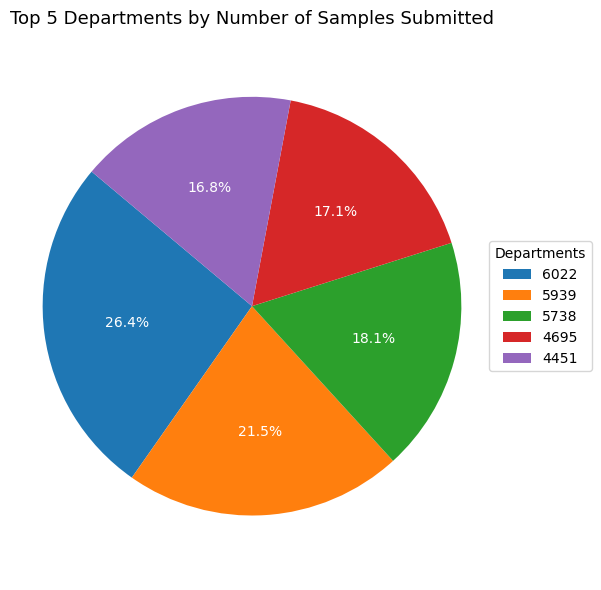

In [118]:
# 11. Which departments submitted the most samples?

# Count samples per department
dept_counts = df['DeptCode'].value_counts().reset_index()
dept_counts.columns = ['DeptCode', 'SampleCount']

# Take top 5 departments
top_departments = dept_counts.head(5)

# Define colors
colors = plt.cm.tab10.colors[:5]

# Pie chart (smaller)
plt.figure(figsize=(6, 6))
wedges, texts, autotexts = plt.pie(
    top_departments['SampleCount'],
    labels=None,  # Legend instead of slice labels
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    textprops={'color': 'w', 'fontsize': 10}
)

# Add legend
plt.legend(
    wedges,
    top_departments['DeptCode'],
    title="Departments",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1),
    fontsize=10
)

plt.title('Top 5 Departments by Number of Samples Submitted', fontsize=13)
plt.axis('equal')  # Keeps the pie circular
plt.tight_layout()
plt.show()

# Conclusion
top_dept = top_departments.iloc[0]


result = f"<p>Department <strong>{top_dept['DeptCode']}</strong> submitted the most samples with <strong>{top_dept['SampleCount']}</strong> total.</p>"
display(HTML(f"<div style='font-size:18px; font-weight:bold;'>{result}</div>"))




# 12. Which Projects submitted the most samples?

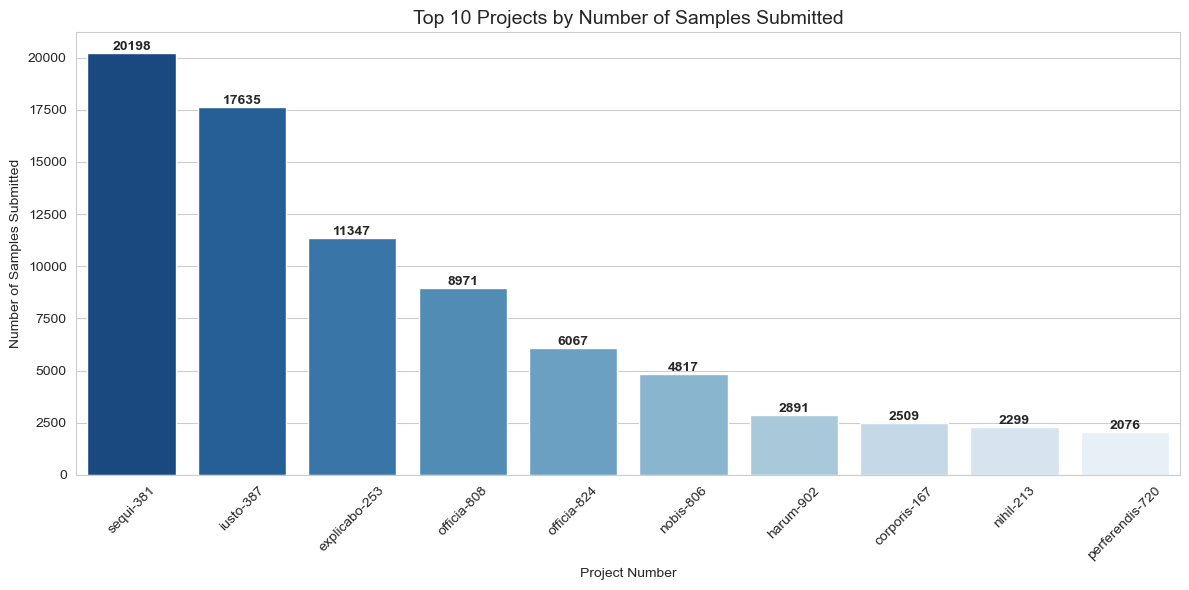

╒════════════════════╤═════════════════╤════════════════╤════════════════════╕
│ Category           │ Project Count   │ Sample Count   │ % of All Samples   │
╞════════════════════╪═════════════════╪════════════════╪════════════════════╡
│ Top 10 Projects    │ 10              │ 78,810         │ 49.8%              │
├────────────────────┼─────────────────┼────────────────┼────────────────────┤
│ All Other Projects │ 2561            │ 79,562         │ 50.2%              │
├────────────────────┼─────────────────┼────────────────┼────────────────────┤
│                    │                 │                │                    │
├────────────────────┼─────────────────┼────────────────┼────────────────────┤
│ Total              │ 2571            │ 158,372        │ 100.0%             │
╘════════════════════╧═════════════════╧════════════════╧════════════════════╛


In [120]:
# 12. Which projects submitted the most samples? 

# Count samples per project
project_counts = df['ProjectNumber'].value_counts().reset_index()
project_counts.columns = ['ProjectNumber', 'SampleCount']

# Get top 10 projects
top_projects = project_counts.head(10)

# Sort ascending for correct color mapping (darkest = biggest)
top_projects = top_projects.sort_values('SampleCount', ascending=True)

# Generate sequential blue colors
colors = sns.color_palette("Blues", n_colors=len(top_projects))

result = 'Top 10 Projects by Number of Samples Submitted'
display(HTML(f"<p style='font-size:18px; font-weight:bold; '>{result}</p>"))

# Sort top_projects by SampleCount in descending order (highest to lowest)
top_projects = top_projects.sort_values('SampleCount', ascending=False)

# Plot bar chart

# Create a dark-to-light color palette
colors = sns.color_palette("Blues_r", n_colors=len(top_projects))  # _r reverses it (dark to light)

plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
barplot = sns.barplot(
    data=top_projects,
    x='ProjectNumber',
    y='SampleCount',
    hue='ProjectNumber',   # Required for palette mapping
    palette=colors,
    dodge= False,
    legend=False           # Hide the hue legend
)

# Add values on top of bars
for i, (index, row) in enumerate(top_projects.iterrows()):
    barplot.text(i, row['SampleCount'] + 1, str(row['SampleCount']), 
                ha='center', va='bottom', fontweight='bold')

plt.title('Top 10 Projects by Number of Samples Submitted', fontsize=14)
plt.xlabel('Project Number')
plt.ylabel('Number of Samples Submitted')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Comparison analysis: Top 10 projects vs all others
total_samples_all_projects = len(df)
top_10_samples = top_projects['SampleCount'].sum()
remaining_samples = total_samples_all_projects - top_10_samples
remaining_projects = len(project_counts) - 10

# Create comparison summary
comparison_data = [
    ["Top 10 Projects", 10, f"{top_10_samples:,}", f"{(top_10_samples/total_samples_all_projects)*100:.1f}%"],
    ["All Other Projects", remaining_projects, f"{remaining_samples:,}", f"{(remaining_samples/total_samples_all_projects)*100:.1f}%"],
    ["", "", "", ""],
    ["Total", len(project_counts), f"{total_samples_all_projects:,}", "100.0%"]
]

comparison_headers = ["Category", "Project Count", "Sample Count", "% of All Samples"]

result = "PROJECT DISTRIBUTION COMPARISON:"
display(HTML(f"<br> <p style='font-size:16px; font-weight:bold; '>{result}</p>"))

print(tabulate(comparison_data, headers=comparison_headers, tablefmt="fancy_grid"))

# Key insights
key_insights_html = f"""
<div style="font-size: 18px; line-height: 1.6;">
    <h1 style="color: #2c5aa0;">Key Insights</h1>
    <ul>
        <li>Top 10 projects represent only <strong>{(10/len(project_counts)*100):.1f}%</strong> of all projects</li>
        <li>But they account for <strong>{(top_10_samples/total_samples_all_projects)*100:.1f}%</strong> of all samples submitted</li>
        <li>The remaining <strong>{remaining_projects}</strong> projects handle <strong>{(remaining_samples/total_samples_all_projects)*100:.1f}%</strong> of samples</li>
        <li>Top project '<strong>{top_projects.iloc[0]['ProjectNumber']}</strong>' alone has <strong>{top_projects.iloc[0]['SampleCount']:,}</strong> samples</li>
    </ul>
</div>
"""
display(HTML(key_insights_html))

# Conclusion in HTML
top_project = top_projects.iloc[-1]  # largest = darkest
conclusion_html = f"""
<div style= padding:16px; border-left:4px solid #2196f3; margin:15px 0;'>
<p style='font-size:18px; margin:0;'><strong>Project {top_project['ProjectNumber']}</strong> submitted the most samples, with a total of <strong>{top_project['SampleCount']}</strong> .</p>
</div>
"""
display(HTML(conclusion_html))

# 13.Can you tell what Projects came from what Departments? 

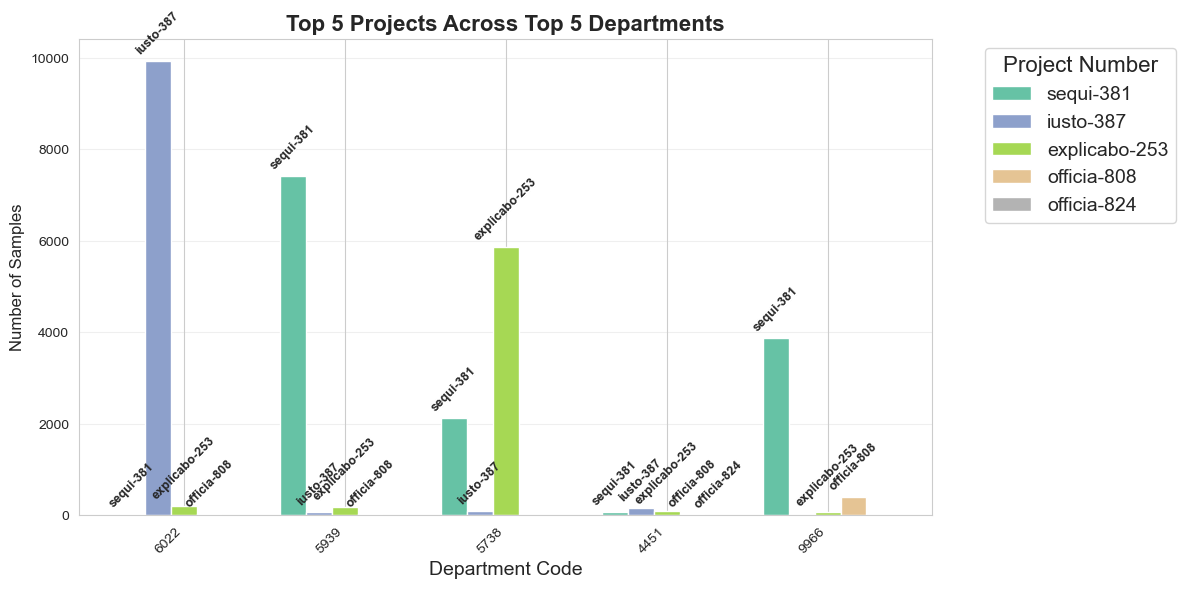

# Overall Statistics

## Summary
- **Total Departments:** 244
- **Total Projects:** 2571
- **Total Samples:** 139168
- **Average samples per department:** 570.4
- **Average samples per project:** 54.1

## Top 5 Departments (by total samples)
1. **6022:** 13158 samples across 236 projects
2. **5939:** 12025 samples across 176 projects
3. **5738:** 10923 samples across 49 projects
4. **4451:** 10308 samples across 148 projects
5. **9966:** 9689 samples across 119 projects

## Most Diverse Departments (by number of different projects)
1. **6022:** 236 different projects (13158 total samples)
2. **7801:** 186 different projects (618 total samples)
3. **1026:** 184 different projects (1082 total samples)
4. **5939:** 176 different projects (12025 total samples)
5. **4059:** 157 different projects (2664 total samples)

## Project Concentration
- **Projects used by only 1 department:** 2357
- **Projects used by multiple departments:** 214
- **Most widely used project:** vitae-507 (28 departments)

In [122]:
# 13.Can you tell what projects came from what departments?

# CREATE REQUIRED VARIABLES FIRST
pivot_table = pd.crosstab(df['DeptCode'], df['ProjectNumber'], margins=False)

# Create dept_summary
dept_summary = pd.DataFrame({
    'Total Samples': pivot_table.sum(axis=1),
    'Unique Projects': (pivot_table > 0).sum(axis=1)
}).sort_values('Total Samples', ascending=False)

# Select fewer projects for clarity
top_5_depts = pivot_table.sum(axis=1).nlargest(5).index
top_5_projects = pivot_table.sum(axis=0).nlargest(5).index
clean_data = pivot_table.loc[top_5_depts, top_5_projects]

ax = clean_data.plot(kind='bar', 
                     figsize=(12, 6),
                     width=0.8,
                     colormap='Set2')

# Add project numbers on top of bars with rotation
for container, project in zip(ax.containers, clean_data.columns):
    labels = [project if v > 0 else '' for v in container.datavalues]
    ax.bar_label(container, labels=labels, padding=3, fontsize=9, fontweight='bold', rotation=45)

plt.title('Top 5 Projects Across Top 5 Departments', fontsize=16, fontweight='bold')
plt.xlabel('Department Code', fontsize=14)
plt.ylabel('Number of Samples', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Project Number', bbox_to_anchor=(1.05, 1), loc='upper left',
           fontsize=14,           # Makes legend text bigger
           title_fontsize=16)     # Makes legend title bigger
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


# SUMMARY STATISTICS 
result = "COMPREHENSIVE ANALYSIS SUMMARY"
display(HTML(f"<br> <p style='font-size:16px; font-weight:bold; '>{result}</p>"))

# Generate markdown sections
def generate_top5_departments(dept_summary):
    lines = []
    for i, (dept, count) in enumerate(dept_summary.head()['Total Samples'].items(), 1):
        projects = dept_summary.loc[dept, 'Unique Projects']
        lines.append(f"{i}. **{dept}:** {count} samples across {projects} projects")
    return "\n".join(lines)

def generate_diversity_departments(pivot_table):
    lines = []
    dept_diversity_full = (pivot_table > 0).sum(axis=1).sort_values(ascending=False)
    for i, (dept, projects) in enumerate(dept_diversity_full.head().items(), 1):
        samples = pivot_table.sum(axis=1)[dept]
        lines.append(f"{i}. **{dept}:** {projects} different projects ({samples} total samples)")
    return "\n".join(lines)

# Generate the sections
dept_top5_md = generate_top5_departments(dept_summary)
dept_diversity_md = generate_diversity_departments(pivot_table)

# Project distribution analysis
single_dept_projects = (pivot_table > 0).sum(axis=0)
single_dept_count = (single_dept_projects == 1).sum()
multi_dept_count = (single_dept_projects > 1).sum()

# Create complete markdown
overall_stats_md = f"""# Overall Statistics

## Summary
- **Total Departments:** {len(pivot_table.index)}
- **Total Projects:** {len(pivot_table.columns)}
- **Total Samples:** {pivot_table.sum().sum()}
- **Average samples per department:** {pivot_table.sum(axis=1).mean():.1f}
- **Average samples per project:** {pivot_table.sum(axis=0).mean():.1f}

## Top 5 Departments (by total samples)
{dept_top5_md}

## Most Diverse Departments (by number of different projects)
{dept_diversity_md}

## Project Concentration
- **Projects used by only 1 department:** {single_dept_count}
- **Projects used by multiple departments:** {multi_dept_count}
- **Most widely used project:** {single_dept_projects.idxmax()} ({single_dept_projects.max()} departments)"""


display(Markdown(overall_stats_md))


# 14.How did the number of samples submitted per Technique change over time? 

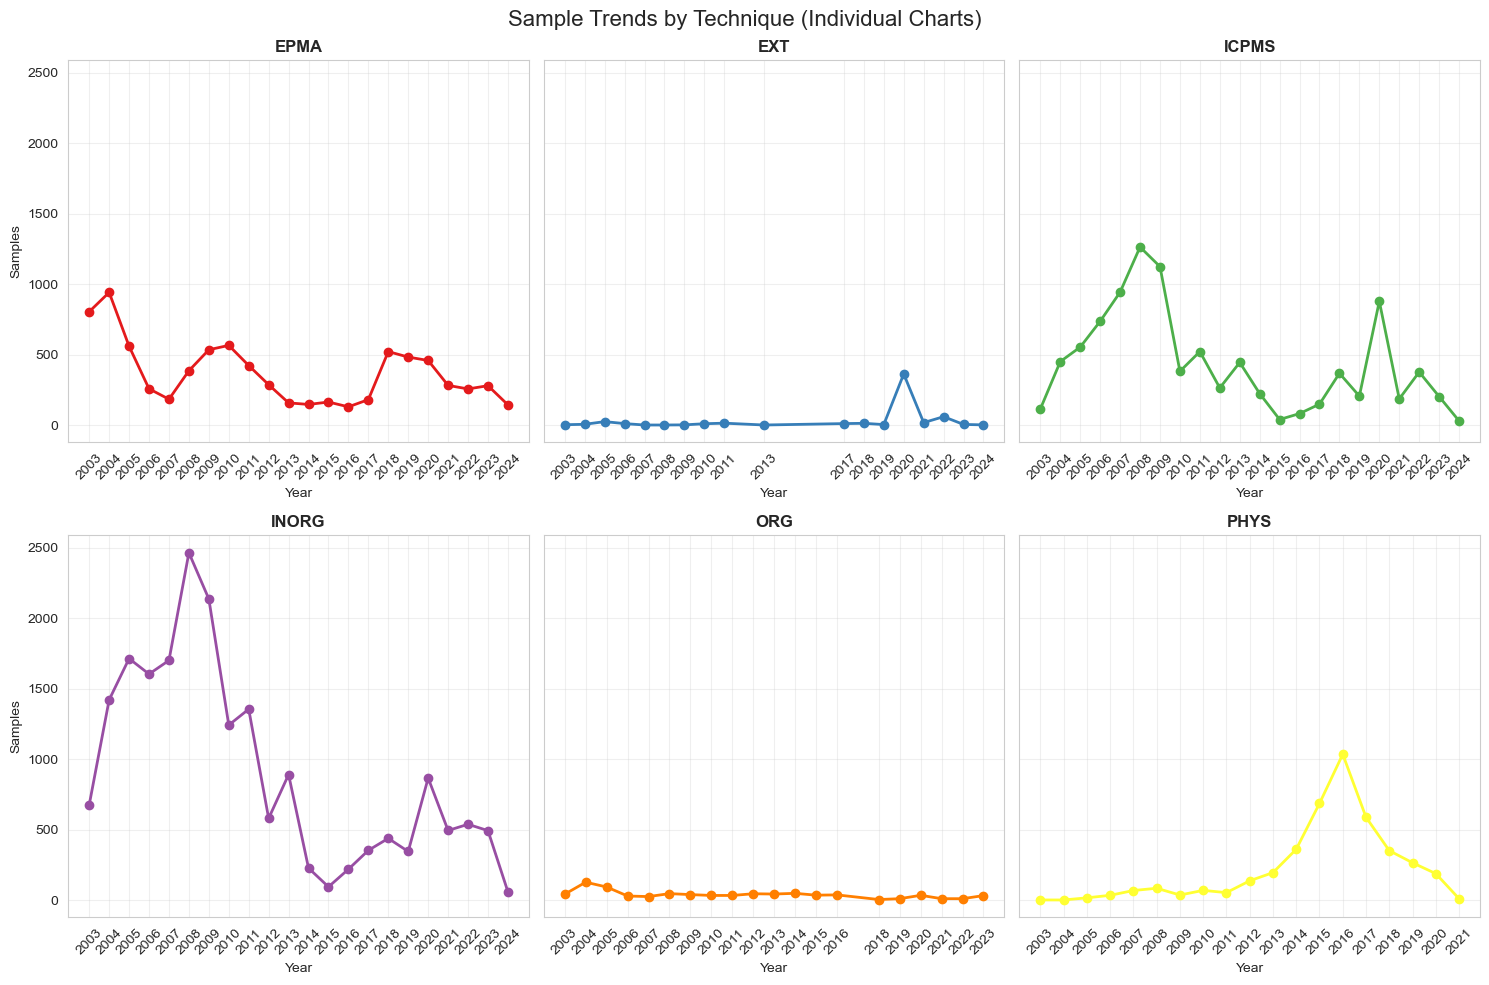

In [124]:
# 14.How did the number of samples submitted per technique change over time? 

# Prepare the data (same as before)
df['SubmitDate'] = pd.to_datetime(df['SubmitDate'], errors='coerce')
df = df.dropna(subset=['SubmitDate', 'Technique'])
df['Year'] = df['SubmitDate'].dt.year
yearly_counts = df.groupby(['Year', 'Technique']).size().reset_index(name='SampleCount')

# Faceted Line Charts - Separate subplot for each technique
fig, axes = plt.subplots(2, 3, figsize=(15, 10), sharey=True)
axes = axes.flatten()
techniques = yearly_counts['Technique'].unique()
colors = plt.cm.Set1(range(len(techniques)))

for i, technique in enumerate(techniques):
    if i < len(axes):
        technique_data = yearly_counts[yearly_counts['Technique'] == technique]
        axes[i].plot(technique_data['Year'], technique_data['SampleCount'], 
                    marker='o', linewidth=2, color=colors[i], markersize=6)
        axes[i].set_title(f'{technique}', fontsize=12, fontweight='bold')
        axes[i].grid(True, alpha=0.3)
        axes[i].set_xlabel('Year')
        
        # Fix x-axis to show years as integers
        axes[i].set_xticks(technique_data['Year'])  # Set ticks to actual year values
        axes[i].tick_params(axis='x', rotation=45)  # Optional: rotate labels if crowded
        
        if i % 3 == 0:  # Only leftmost plots get y-label
            axes[i].set_ylabel('Samples')

# Hide unused subplots
for j in range(len(techniques), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Sample Trends by Technique (Individual Charts)', fontsize=16)
plt.tight_layout()
plt.show()


# Summary statistics to accompany the charts
first_year = yearly_counts['Year'].min()
last_year = yearly_counts['Year'].max()

# Start building the HTML
summary_html = f"""
<div style="border: 1px solid #ccc; padding: 20px; margin: 15px 0; background-color: #f9f9f9;">
    <h2 style="color: #2E7D32; margin-top: 0;">📈 TECHNIQUE TRENDS SUMMARY</h2>
    <hr style="border: 1px solid #ccc; margin: 15px 0;">
"""

# Overall growth by technique
for technique in yearly_counts['Technique'].unique():
    tech_data = yearly_counts[yearly_counts['Technique'] == technique]
    first_count = tech_data[tech_data['Year'] == first_year]['SampleCount'].sum()
    last_count = tech_data[tech_data['Year'] == last_year]['SampleCount'].sum()
    total_samples = tech_data['SampleCount'].sum()
    
    if first_count > 0:
        growth = ((last_count - first_count) / first_count) * 100
        peak_year = tech_data.loc[tech_data['SampleCount'].idxmax(), 'Year']
        
        # Color code the growth percentage
        growth_color = "#4CAF50" if growth >= 0 else "#f44336"
        growth_sign = "+" if growth >= 0 else ""
        
        summary_html += f"""
        <div style="background-color: white; padding: 15px; margin: 10px 0; border-left: 4px solid #2196F3; border-radius: 5px;">
            <h4 style="color: #1976D2; margin: 0 0 10px 0;">{technique}</h4>
            <ul style="margin: 0; padding-left: 20px;">
                <li><strong>Total samples:</strong> {total_samples:,}</li>
                <li><strong>Growth from {first_year} to {last_year}:</strong> 
                    <span style="color: {growth_color}; font-weight: bold;">{growth_sign}{growth:.1f}%</span></li>
                <li><strong>Peak year:</strong> {peak_year}</li>
            </ul>
        </div>
        """

summary_html += """
</div>
"""

display(HTML(summary_html))
# final statement


result = "This analysis shows that the majority of techniques have a drop in the number of samples."
display(HTML(f"<p style='font-size:16px; color:#333;'><b>{result}</b></p>"))



# **15. Were there any outliers (e.g., EXT technique) that could be cleaned?**  

**We do not have sufficient information about EXT Techniques — what type of Techniques they are, nor whether they were performed in the JM lab or in external laboratories.**  

**Therefore, this analysis assumes that EXT was performed in the JM lab. To estimate the potential impact of EXT on other Techniques, our approach was as follows:**  

**First variant**
**1. Identify all Analysts who used EXT.**  
**2. Select the top EXT Analyst and list all Techniques he/she worked with.**  
**3. Make assumptions about the impact if `EXT = XRD` and if `EXT = HES`.**  

**Second variant:**
**1. Identify all Submitters who used EXT.**  
**2. Select the top EXT Submitter and list all Techniques he/she worked with.**  
**3. Make assumptions about the impact if `EXT = SEM` and if `EXT = LNMR`.**  



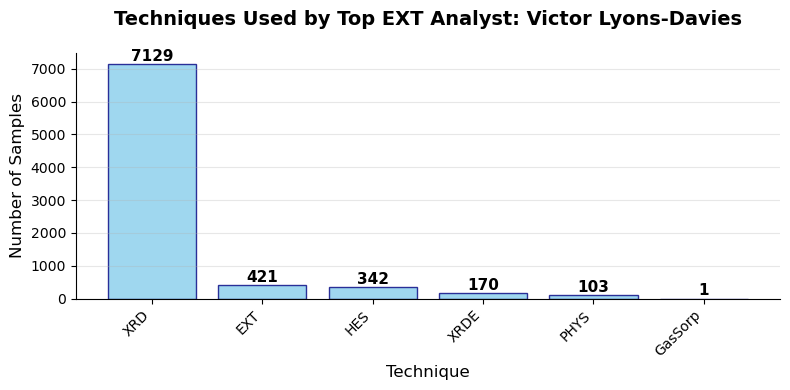

Scenario,EXT Count,XRD Count,HES Count,Replaced Technique
Original,421,7129,342,EXT
EXT = XRD,7129,7550,421,EXT
EXT = HES,342,7129,763,EXT


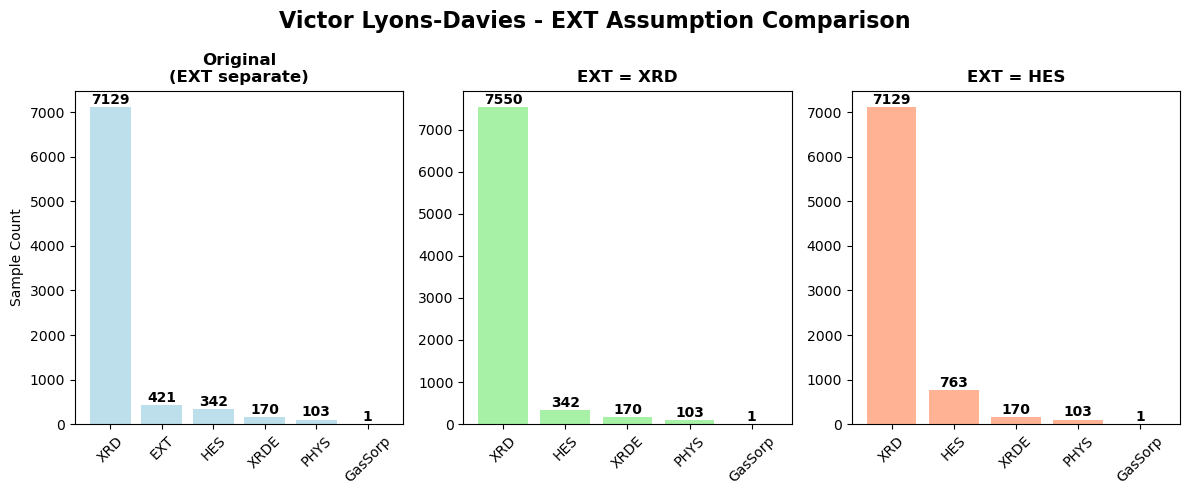

In [3]:
# analyse made around AnalystName

# first, find all the analyst that worked with ext
analyst_ext = df[df['Technique'] == 'EXT'].groupby('AnalystName').size()              
top_analyst_ext = analyst_ext.idxmax()                                                
techniques_top_ext = df[df['AnalystName'] == top_analyst_ext]['Technique'].unique()    

# Get the ORIGINAL technique counts for this analyst
original_techniques = (
    df[df['AnalystName'] == top_analyst_ext]
    .groupby('Technique')
    .size()
    .sort_values(ascending=False)
)

# Create HTML display for EXT analyst results
result_html = f"""
<div style="border: 1px solid #ccc; padding: 15px; margin: 10px 0; background-color: #f9f9f9;">
    <h3>🔬 Top EXT Analyst </h3>
    <p><strong>Top EXT Analyst:</strong> {top_analyst_ext}</p>
    <p><strong>Total EXT samples by this analyst:</strong> {analyst_ext[top_analyst_ext]}</p>
</div>
"""

display(HTML(result_html))

# Create bar chart
plt.figure(figsize=(8, 4))
bars = plt.bar(original_techniques.index, original_techniques.values, 
               color='skyblue', alpha=0.8, edgecolor='navy', linewidth=1)

# Add values on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{int(height)}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title(f'Techniques Used by Top EXT Analyst: {top_analyst_ext}', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Technique', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Add some styling
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# Now test both assumptions for THIS SAME ANALYST

# Assumption 1: EXT = XRD
df_xrd = df[df['AnalystName'] == top_analyst_ext].copy()
df_xrd['Technique'] = df_xrd['Technique'].replace('EXT', 'XRD')
xrd_techniques = df_xrd.groupby('Technique').size().sort_values(ascending=False)

# Assumption 2: EXT = HES
df_hes = df[df['AnalystName'] == top_analyst_ext].copy()
df_hes['Technique'] = df_hes['Technique'].replace('EXT', 'HES')
hes_techniques = df_hes.groupby('Technique').size().sort_values(ascending=False)

# Simple comparison HTML
comparison_html = f"""
<div style="border: 1px solid #ccc; padding: 20px; margin: 15px 0; background-color: #f9f9f9;">
    <h3>🔬 {top_analyst_ext} - EXT Assumption Impact</h3>
    
    <table style="width: 100%; border-collapse: collapse; margin: 15px 0;">
        <tr style="background-color: #e3f2fd;">
            <th style="padding: 10px; border: 1px solid #ddd; text-align: left;">Scenario</th>
            <th style="padding: 10px; border: 1px solid #ddd; text-align: center;">EXT Count</th>
            <th style="padding: 10px; border: 1px solid #ddd; text-align: center;">XRD Count</th>
            <th style="padding: 10px; border: 1px solid #ddd; text-align: center;">HES Count</th>
            <th style="padding: 10px; border: 1px solid #ddd; text-align: center;">Replaced Technique</th>
        </tr>
        <tr>
            <td style="padding: 8px; border: 1px solid #ddd;"><strong>Original</strong></td>
            <td style="padding: 8px; border: 1px solid #ddd; text-align: center;">{original_techniques.get('EXT', 0)}</td>
            <td style="padding: 8px; border: 1px solid #ddd; text-align: center;">{original_techniques.get('XRD', 0)}</td>
            <td style="padding: 8px; border: 1px solid #ddd; text-align: center;">{original_techniques.get('HES', 0)}</td>
            <td style="padding: 8px; border: 1px solid #ddd; text-align: center;">EXT</td>
        </tr>
        <tr style="background-color: #e8f5e8;">
            <td style="padding: 8px; border: 1px solid #ddd;"><strong>EXT = XRD</strong></td>
            <td style="padding: 8px; border: 1px solid #ddd; text-align: center;">{original_techniques.get('XRD', 0)}</td> 
            <td style="padding: 8px; border: 1px solid #ddd; text-align: center; font-weight: bold; color: green;">{xrd_techniques.get('XRD', 0)}</td>
            <td style="padding: 8px; border: 1px solid #ddd; text-align: center;">{original_techniques.get('EXT', 0)}</td> 
            <td style="padding: 8px; border: 1px solid #ddd; text-align: center;">EXT</td>
        </tr>
        <tr style="background-color: #fff3e0;">
            <td style="padding: 8px; border: 1px solid #ddd;"><strong>EXT = HES</strong></td>
            <td style="padding: 8px; border: 1px solid #ddd; text-align: center;">{original_techniques.get('HES', 0)}</td>
            <td style="padding: 8px; border: 1px solid #ddd; text-align: center;">{hes_techniques.get('XRD', 0)}</td>
            <td style="padding: 8px; border: 1px solid #ddd; text-align: center; font-weight: bold; color: orange;">{hes_techniques.get('HES', 0)}</td>
            <td style="padding: 8px; border: 1px solid #ddd; text-align: center;">EXT</td>
        </tr>
    </table>
    
    <h4>📊 Impact Summary:</h4>
    <ul>
        <li><strong>EXT samples to reassign:</strong> {original_techniques.get('EXT', 0)}</li>
        <li><strong>If EXT = XRD:</strong> XRD increases by {original_techniques.get('EXT', 0)} (from {original_techniques.get('XRD', 0)} to {xrd_techniques.get('XRD', 0)})</li>
        <li><strong>If EXT = HES:</strong> HES increases by {original_techniques.get('EXT', 0)} (from {original_techniques.get('HES', 0)} to {hes_techniques.get('HES', 0)})</li>
    </ul>
</div>
"""

display(HTML(comparison_html))

# Simple 3-way bar chart comparison
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 5))

# Original
bars1 = ax1.bar(original_techniques.index, original_techniques.values, color='lightblue', alpha=0.8)
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.5, f'{int(height)}', 
             ha='center', va='bottom', fontweight='bold')
ax1.set_title('Original\n(EXT separate)', fontweight='bold')
ax1.set_ylabel('Sample Count')
ax1.tick_params(axis='x', rotation=45)

# EXT = XRD
bars2 = ax2.bar(xrd_techniques.index, xrd_techniques.values, color='lightgreen', alpha=0.8)
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.5, f'{int(height)}', 
             ha='center', va='bottom', fontweight='bold')
ax2.set_title('EXT = XRD', fontweight='bold')
ax2.tick_params(axis='x', rotation=45)

# EXT = HES
bars3 = ax3.bar(hes_techniques.index, hes_techniques.values, color='lightsalmon', alpha=0.8)
for bar in bars3:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + 0.5, f'{int(height)}', 
             ha='center', va='bottom', fontweight='bold')
ax3.set_title('EXT = HES', fontweight='bold')
ax3.tick_params(axis='x', rotation=45)

plt.suptitle(f'{top_analyst_ext} - EXT Assumption Comparison', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Calculate percentages correctly - using max() to avoid division by zero
xrd_original = original_techniques.get('XRD', 0)
hes_original = original_techniques.get('HES', 0)

# Only calculate percentage if original value > 0
if xrd_original > 0:
    xrd_percent = round(((xrd_techniques.get('XRD', 0) - xrd_original) / xrd_original) * 100)
else:
    xrd_percent = "N/A (no original XRD samples)"

if hes_original > 0:
    hes_percent = round(((hes_techniques.get('HES', 0) - hes_original) / hes_original) * 100)
else:
    hes_percent = "N/A (no original HES samples)"

# Generate simple HTML
html_content = f"""
<div style="font-family: Arial; padding: 20px; max-width: 600px; margin: 0 auto; border: 1px solid #ddd;">
    <h1 style="color: #2c5aa0; text-align: center;">🔬 EXT Impact Analysis for {top_analyst_ext}</h1>
    
    <div style="background: #f8f9fa; padding: 15px; margin: 20px 0;">
        <strong>Analyst:</strong> {top_analyst_ext}<br>
        <strong>EXT samples to reassign:</strong> {original_techniques.get('EXT', 0)}
    </div>
    
    <div style="background: #f0f8ff; padding: 15px; margin: 15px 0; border-left: 3px solid #2c5aa0;">
        <h3>If EXT = XRD:</h3>
        <p>XRD: {xrd_original} → <strong style="color: #5cb85c;">{xrd_techniques.get('XRD', 0)}</strong></p>
        <p style="color: #d9534f; font-weight: bold;">Impact: {xrd_percent}{'% increase' if isinstance(xrd_percent, int) else ''}</p>
    </div>
    
    <div style="background: #f0f8ff; padding: 15px; margin: 15px 0; border-left: 3px solid #2c5aa0;">
        <h3>If EXT = HES:</h3>
        <p>HES: {hes_original} → <strong style="color: #5cb85c;">{hes_techniques.get('HES', 0)}</strong></p>
        <p style="color: #d9534f; font-weight: bold;">Impact: {hes_percent}{'% increase' if isinstance(hes_percent, int) else ''}</p>
    </div>
</div>
"""

HTML(html_content)


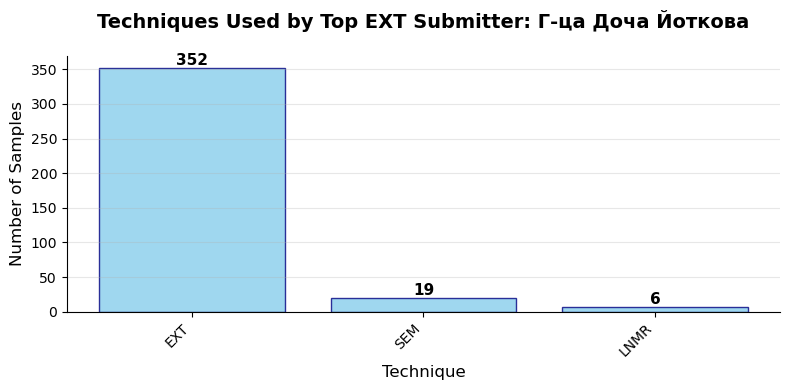

Scenario,EXT Count,SEM Count,LNMR Count,Replaced Technique
Original,352,19,6,EXT
EXT = SEM,19,371,352,EXT
EXT = LNMR,6,19,358,EXT


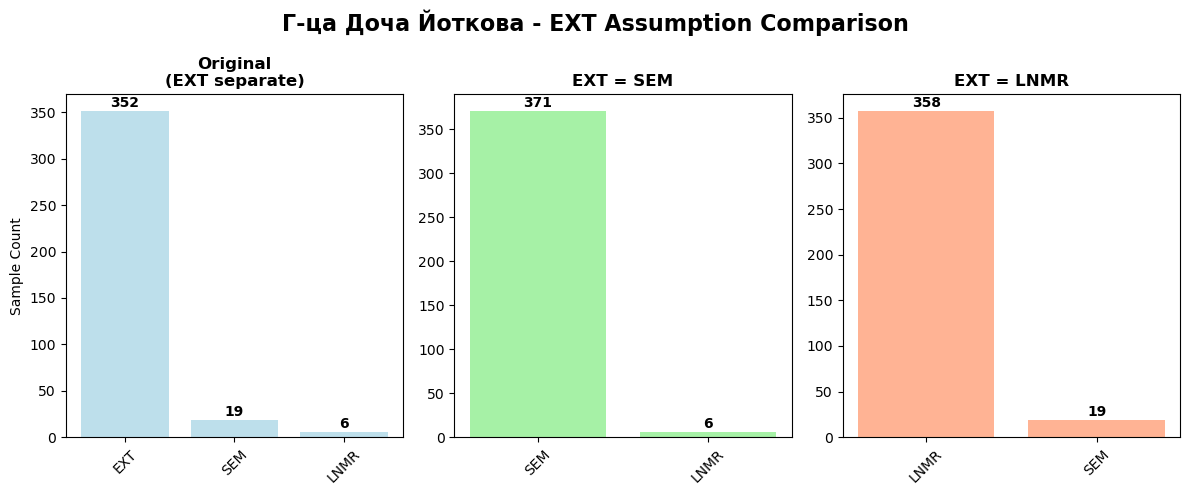

In [5]:
# first, find all the submitters that worked witk ext

submitter_ext = df[df['Technique'] == 'EXT'].groupby('SubmitterName').size()              # finding the name and count of EXT
top_submitter_ext = submitter_ext.idxmax()                                                # find the top EXT submitter

# Get original technique counts for the top EXT submitter
original_techniques = (
    df[df['SubmitterName'] == top_submitter_ext]
    .groupby('Technique')
    .size()
    .sort_values(ascending=False)
)

# Create HTML display for EXT submitter results
result_html = f"""
<div style="border: 1px solid #ccc; padding: 15px; margin: 10px 0; background-color: #f9f9f9;">
    <h3>🔬 Top EXT Submitter </h3>
    <p><strong>Top EXT Submitter:</strong> {top_submitter_ext}</p>
    <p><strong>Total EXT samples by this Submitter:</strong> {submitter_ext[top_submitter_ext]}</p>
</div>
"""

display(HTML(result_html))

# Create bar chart
plt.figure(figsize=(8, 4))
bars = plt.bar(original_techniques.index, original_techniques.values, 
               color='skyblue', alpha=0.8, edgecolor='navy', linewidth=1)

# Add values on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{int(height)}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title(f'Techniques Used by Top EXT Submitter: {top_submitter_ext}', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Technique', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Add some styling
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# Now test both assumptions for THIS SAME SUBMITTER

# Assumption 1: EXT = SEM
df_sem = df[df['SubmitterName'] == top_submitter_ext].copy()
df_sem['Technique'] = df_sem['Technique'].replace('EXT', 'SEM')
sem_techniques = df_sem.groupby('Technique').size().sort_values(ascending=False)

# Assumption 2: EXT = LNMR
df_lnmr = df[df['SubmitterName'] == top_submitter_ext].copy()  # Fixed: was AnalystName
df_lnmr['Technique'] = df_lnmr['Technique'].replace('EXT', 'LNMR')
lnmr_techniques = df_lnmr.groupby('Technique').size().sort_values(ascending=False)

# Simple comparison HTML - FIXED: All "Substitute Technique" values should be "EXT"
comparison_html = f"""
<div style="border: 1px solid #ccc; padding: 20px; margin: 15px 0; background-color: #f9f9f9;">
    <h3>🔬 {top_submitter_ext} - EXT Assumption Impact</h3>
    
    <table style="width: 100%; border-collapse: collapse; margin: 15px 0;">
        <tr style="background-color: #e3f2fd;">
            <th style="padding: 10px; border: 1px solid #ddd; text-align: left;">Scenario</th>
            <th style="padding: 10px; border: 1px solid #ddd; text-align: center;">EXT Count</th>
            <th style="padding: 10px; border: 1px solid #ddd; text-align: center;">SEM Count</th>
            <th style="padding: 10px; border: 1px solid #ddd; text-align: center;">LNMR Count</th>
            <th style="padding: 10px; border: 1px solid #ddd; text-align: center;">Replaced Technique</th>
        </tr>
        <tr>
            <td style="padding: 8px; border: 1px solid #ddd;"><strong>Original</strong></td>
            <td style="padding: 8px; border: 1px solid #ddd; text-align: center;">{original_techniques.get('EXT', 0)}</td>
            <td style="padding: 8px; border: 1px solid #ddd; text-align: center;">{original_techniques.get('SEM', 0)}</td>
            <td style="padding: 8px; border: 1px solid #ddd; text-align: center;">{original_techniques.get('LNMR', 0)}</td>
            <td style="padding: 8px; border: 1px solid #ddd; text-align: center;">EXT</td>
        </tr>
        <tr style="background-color: #e8f5e8;">
            <td style="padding: 8px; border: 1px solid #ddd;"><strong>EXT = SEM</strong></td>
            <td style="padding: 8px; border: 1px solid #ddd; text-align: center;">{original_techniques.get('SEM', 0)}</td>
            <td style="padding: 8px; border: 1px solid #ddd; text-align: center; font-weight: bold; color: green;">{sem_techniques.get('SEM', 0)}</td>
            <td style="padding: 8px; border: 1px solid #ddd; text-align: center;">{original_techniques.get('EXT', 0)}</td> 
            <td style="padding: 8px; border: 1px solid #ddd; text-align: center;">EXT</td>
        </tr>
        <tr style="background-color: #fff3e0;">
            <td style="padding: 8px; border: 1px solid #ddd;"><strong>EXT = LNMR</strong></td>
            <td style="padding: 8px; border: 1px solid #ddd; text-align: center;">{original_techniques.get('LNMR', 0)}</td>
            <td style="padding: 8px; border: 1px solid #ddd; text-align: center;">{lnmr_techniques.get('SEM', 0)}</td>
            <td style="padding: 8px; border: 1px solid #ddd; text-align: center; font-weight: bold; color: orange;">{lnmr_techniques.get('LNMR', 0)}</td>
            <td style="padding: 8px; border: 1px solid #ddd; text-align: center;">EXT</td>
        </tr>
    </table>
    
    <h4>📊 Impact Summary:</h4>
    <ul>
        <li><strong>EXT samples to reassign:</strong> {original_techniques.get('EXT', 0)}</li>
        <li><strong>If EXT = SEM:</strong> SEM increases by {original_techniques.get('EXT', 0)} (from {original_techniques.get('SEM', 0)} to {sem_techniques.get('SEM', 0)})</li>
        <li><strong>If EXT = LNMR:</strong> LNMR increases by {original_techniques.get('EXT', 0)} (from {original_techniques.get('LNMR', 0)} to {lnmr_techniques.get('LNMR', 0)})</li>
    </ul>
</div>
"""

display(HTML(comparison_html))

# Simple 3-way bar chart comparison
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 5))

# Original
bars1 = ax1.bar(original_techniques.index, original_techniques.values, color='lightblue', alpha=0.8)
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.5, f'{int(height)}', 
             ha='center', va='bottom', fontweight='bold')
ax1.set_title('Original\n(EXT separate)', fontweight='bold')
ax1.set_ylabel('Sample Count')
ax1.tick_params(axis='x', rotation=45)

# EXT = SEM
bars2 = ax2.bar(sem_techniques.index, sem_techniques.values, color='lightgreen', alpha=0.8)
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.5, f'{int(height)}', 
             ha='center', va='bottom', fontweight='bold')
ax2.set_title('EXT = SEM', fontweight='bold')
ax2.tick_params(axis='x', rotation=45)

# EXT = LNMR
bars3 = ax3.bar(lnmr_techniques.index, lnmr_techniques.values, color='lightsalmon', alpha=0.8)
for bar in bars3:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + 0.5, f'{int(height)}', 
             ha='center', va='bottom', fontweight='bold')
ax3.set_title('EXT = LNMR', fontweight='bold')
ax3.tick_params(axis='x', rotation=45)

plt.suptitle(f'{top_submitter_ext} - EXT Assumption Comparison', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Calculate percentages 
sem_percent = round(((sem_techniques.get('SEM', 0) - original_techniques.get('SEM', 0)) / max(original_techniques.get('SEM', 1), 1)) * 100)
lnmr_percent = round(((lnmr_techniques.get('LNMR', 0) - original_techniques.get('LNMR', 0)) / max(original_techniques.get('LNMR', 1), 1)) * 100)

# Generate simple HTML with percentages
html_content = f"""
<div style="font-family: Arial; padding: 20px; max-width: 600px; margin: 0 auto; border: 1px solid #ddd;">
    <h1 style="color: #2c5aa0; text-align: center;">🔬 EXT Impact Analysis for {top_submitter_ext}</h1>
    
    <div style="background: #f8f9fa; padding: 15px; margin: 20px 0;">
        <strong>Submitter:</strong> {top_submitter_ext}<br>
        <strong>EXT samples to reassign:</strong> {original_techniques.get('EXT', 0)}
    </div>
    
    <div style="background: #f0f8ff; padding: 15px; margin: 15px 0; border-left: 3px solid #2c5aa0;">
        <h3>If EXT = SEM:</h3>
        <p>SEM: {original_techniques.get('SEM', 0)} → <strong style="color: #5cb85c;">{sem_techniques.get('SEM', 0)}</strong></p>
        <p style="color: #d9534f; font-weight: bold;">Impact: +{sem_percent}% increase</p>
    </div>
    
    <div style="background: #f0f8ff; padding: 15px; margin: 15px 0; border-left: 3px solid #2c5aa0;">
        <h3>If EXT = LNMR:</h3>
        <p>LNMR: {original_techniques.get('LNMR', 0)} → <strong style="color: #5cb85c;">{lnmr_techniques.get('LNMR', 0)}</strong></p>
        <p style="color: #d9534f; font-weight: bold;">Impact: +{lnmr_percent}% increase</p>
    </div>
</div>
"""

HTML(html_content)

# 16.What was the turnaround time for each Technique? (EndDate - AcceptDate)

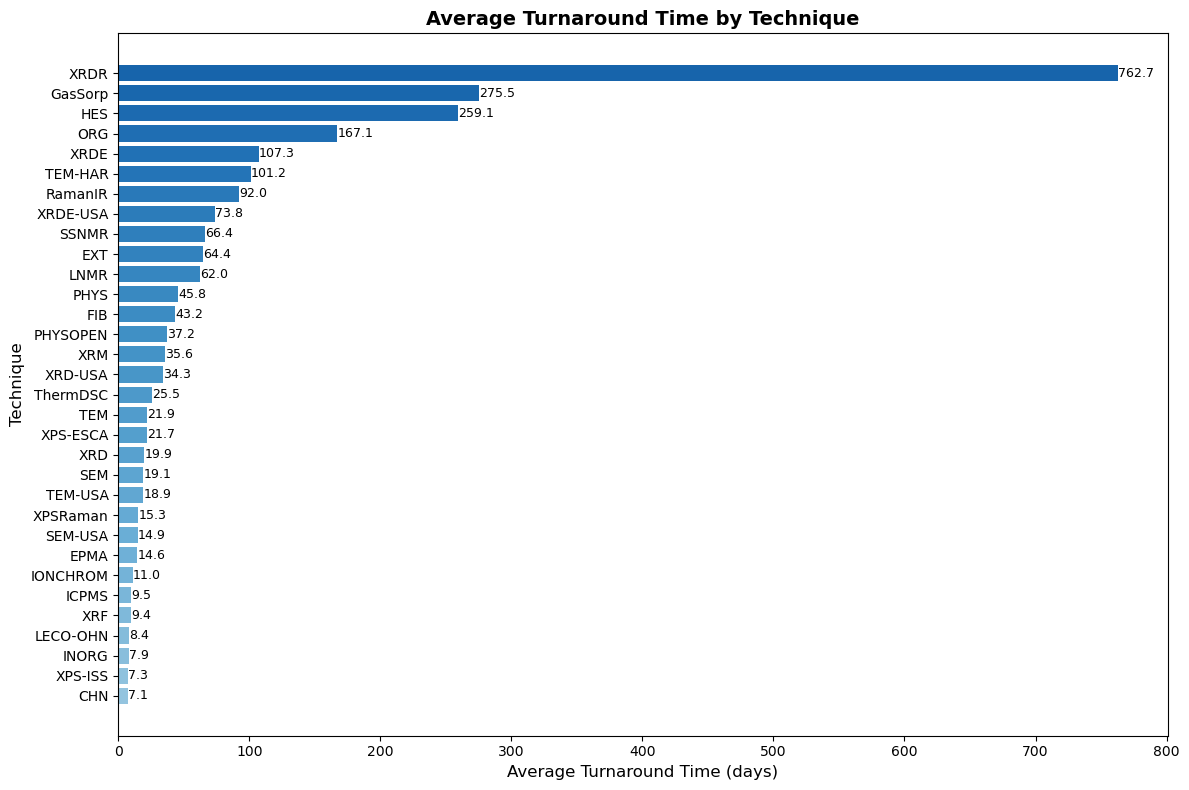

In [134]:
# Convert date columns to datetime
df['AcceptDate'] = pd.to_datetime(df['AcceptDate'], errors='coerce')
df['EndDate'] = pd.to_datetime(df['EndDate'], errors='coerce')

# Calculate turnaround days (this will create NaN for missing dates)
df['TurnaroundDays'] = (df['EndDate'] - df['AcceptDate']).dt.days


# Only filter out negative turnaround days (data errors)
df = df[(df['TurnaroundDays'] > 0) | (df['TurnaroundDays'].isna())]

# Calculate average and median turnaround time per technique
tech_stats = df.groupby('Technique')['TurnaroundDays'].agg(['mean', 'median', 'count']).reset_index()
tech_stats = tech_stats.sort_values('mean', ascending=True)  # For nicer horizontal bar chart

# Plot with clean style
plt.figure(figsize=(12, 8))
plt.style.use('default')  # Reset to default style
plt.grid(False)  # Explicitly turn off grid

bars = plt.barh(
    tech_stats['Technique'], 
    tech_stats['mean'], 
    color=plt.cm.Blues(np.linspace(0.4, 0.8, len(tech_stats)))
)
# Add value labels
for bar, mean in zip(bars, tech_stats['mean']):
    plt.text(mean + 0.2, bar.get_y() + bar.get_height()/2, f'{mean:.1f}', va='center', fontsize=9)

plt.title('Average Turnaround Time by Technique', fontsize=14, fontweight='bold')
plt.xlabel('Average Turnaround Time (days)', fontsize=12)
plt.ylabel('Technique', fontsize=12)
plt.tight_layout()
plt.show()

# print the last statement
result = """XRDR is Technique with longest Turnaround time.
<br> CHN is Technique with shortest Turnaround time"""
display(HTML(f"<br> <p style='font-size:16px; font-weight:bold; '>{result}</p>"))

# 17.Did the turnaround time change over time? 

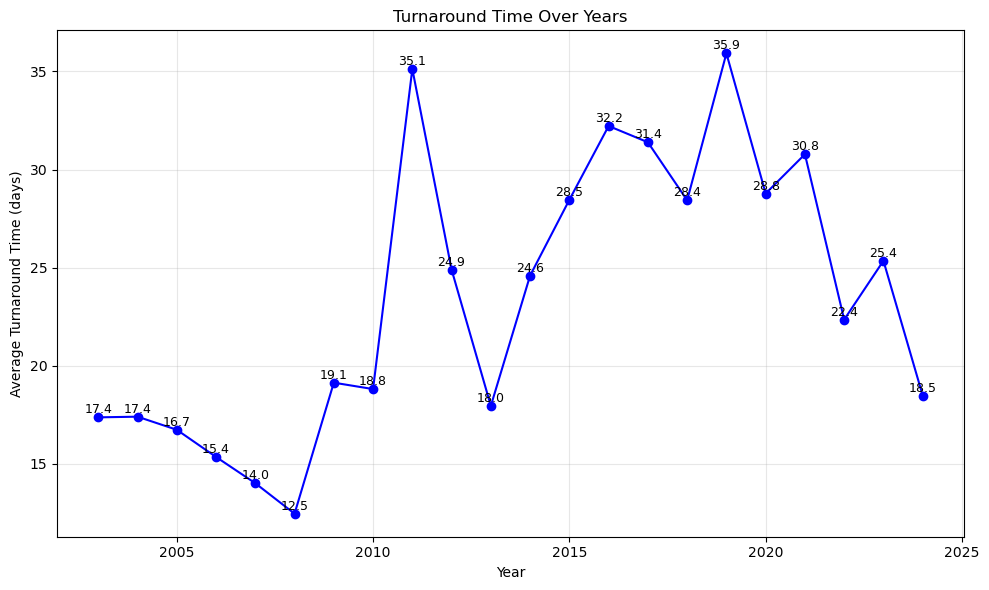

In [136]:
# 17. Did the turnaround time change over time? (aggregated by year)

# Calculate turnaround time in days
df['Turnaround_Time'] = (df['EndDate'] - df['AcceptDate']).dt.days

# Extract year from AcceptDate
df['Year'] = df['AcceptDate'].dt.year

# Calculate average turnaround time per year (using df_1 consistently)
tat_over_time = df.groupby('Year')['Turnaround_Time'].mean().reset_index()

# print the heading
result = "How Turnaround Time Changed Over the Years"
display(HTML(f"<br> <p style='font-size:18px; font-weight:bold; '>{result}</p>"))

# Plot
plt.figure(figsize=(10, 6))
plt.plot(
    tat_over_time['Year'],
    tat_over_time['Turnaround_Time'],
    marker='o',
    color='blue'
)

# Add data labels
for x, y in zip(tat_over_time['Year'], tat_over_time['Turnaround_Time']):
    plt.text(x, y + 0.2, f"{y:.1f}", ha='center', fontsize=9)

plt.xlabel("Year")
plt.ylabel("Average Turnaround Time (days)")
plt.title("Turnaround Time Over Years")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Conclusion
trend_direction = "improved" if tat_over_time['Turnaround_Time'].iloc[-1] < tat_over_time['Turnaround_Time'].iloc[0] else "worsened"
best_year = int(tat_over_time.loc[tat_over_time['Turnaround_Time'].idxmin(), 'Year'])
worst_year = int(tat_over_time.loc[tat_over_time['Turnaround_Time'].idxmax(), 'Year'])

conclusion_html = f"""
<div style='padding:15px; margin:16px 0;font-size:17px;'>
<p><strong>Turnaround Time Trend:</strong> Performance has <strong>{trend_direction}</strong> over time.</p>
<p><strong>Best year:</strong> {best_year} | <strong>Worst year:</strong> {worst_year}</p>
</div>
"""
display(HTML(conclusion_html))


# 18.What was the distribution of turnaround times per Technique? Which Techniques had a normal distribution and which didn't?

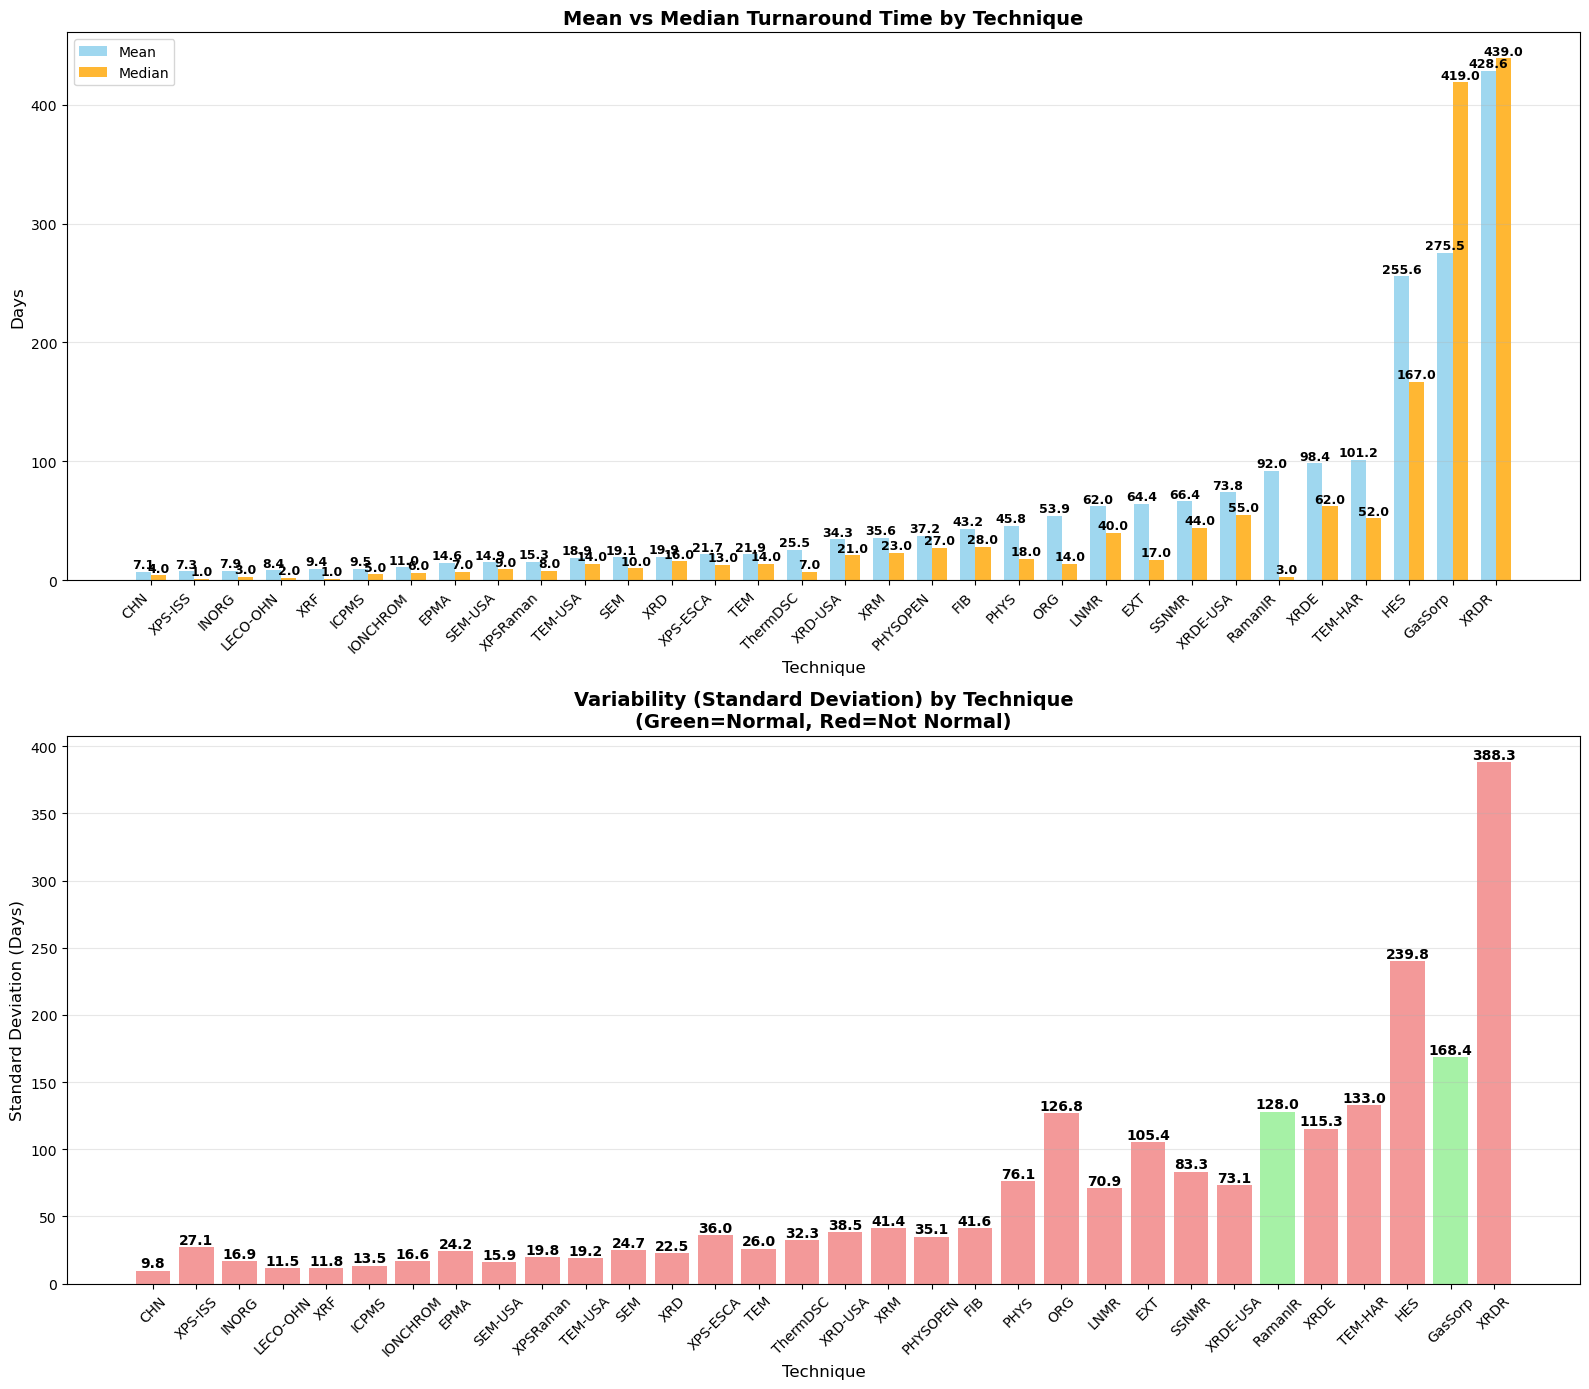

╒═════════════╤════════════════╤═══════════════╤═════════════════╤══════════════════╤════════════════╤═══════════╕
│ Technique   │   Sample Count │   Mean (days) │   Median (days) │   Std Dev (days) │ Distribution   │   P-value │
╞═════════════╪════════════════╪═══════════════╪═════════════════╪══════════════════╪════════════════╪═══════════╡
│ XRD         │          50688 │          19.9 │              16 │             22.5 │ Not Normal     │    0      │
├─────────────┼────────────────┼───────────────┼─────────────────┼──────────────────┼────────────────┼───────────┤
│ XPS-ESCA    │           6046 │          21.7 │              13 │             36   │ Not Normal     │    0      │
├─────────────┼────────────────┼───────────────┼─────────────────┼──────────────────┼────────────────┼───────────┤
│ SEM         │          16292 │          19.1 │              10 │             24.7 │ Not Normal     │    0      │
├─────────────┼────────────────┼───────────────┼─────────────────┼──────────────

In [138]:
# Make sure Turnaround_Time exists
df['Turnaround_Time'] = (df['EndDate'] - df['AcceptDate']).dt.days

# Filter out invalid turnaround times (negative or too large)
df = df[(df['Turnaround_Time'] >= 0) & (df['Turnaround_Time'] <= 1000)]  # reasonable upper limit

# ------------------ Normality Test ------------------
techniques = df['Technique'].unique()
normality_results = {}
turnaround_stats = {}

for tech in techniques:
    data = df[df['Technique'] == tech]['Turnaround_Time'].dropna()
    
    if len(data) >= 8:  # only test if enough samples
        try:
            stat, p = normaltest(data)
            normality_results[tech] = 'Normal' if p > 0.05 else 'Not Normal'
            turnaround_stats[tech] = {
                'mean': data.mean(),
                'median': data.median(),
                'std': data.std(),
                'count': len(data),
                'p_value': p
            }
        except Exception as e:
            # Handle potential statistical test errors
            normality_results[tech] = 'Test Failed'
            turnaround_stats[tech] = {
                'mean': data.mean(),
                'median': data.median(),
                'std': data.std(),
                'count': len(data),
                'p_value': None
            }
    else:
        normality_results[tech] = 'Too few samples'
        turnaround_stats[tech] = {
            'mean': data.mean() if len(data) > 0 else 0,
            'median': data.median() if len(data) > 0 else 0,
            'std': data.std() if len(data) > 0 else 0,
            'count': len(data),
            'p_value': None
        }

# Only use techniques with at least 1 sample
valid_techniques = [t for t in techniques if turnaround_stats[t]['count'] > 0]

# Add import if missing
from scipy.stats import normaltest

# Optional: Display results summary
# HTML summary
summary_html = f"""
<div style=' padding:10px; margin:10px 0;'>
<p style='margin:5px 0; font-size:18px;'><strong> Normality Test Summary:</strong></p>
<p style='margin:5px 0;'>• Normality test completed for <strong>{len(techniques)}</strong> techniques</p>
<p style='margin:5px 0;'>• Valid techniques with data: <strong>{len(valid_techniques)}</strong></p>
</div>
"""
display(HTML(summary_html))

# =================== Charts ===================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 14))

# Chart 1: Mean vs Median comparison
techniques_sorted = sorted(valid_techniques, key=lambda x: turnaround_stats[x]['mean'])
means = [turnaround_stats[tech]['mean'] for tech in techniques_sorted]
medians = [turnaround_stats[tech]['median'] for tech in techniques_sorted]

x_pos = np.arange(len(techniques_sorted))
width = 0.35

bars1 = ax1.bar(x_pos - width/2, means, width, label='Mean', color='skyblue', alpha=0.8)
bars2 = ax1.bar(x_pos + width/2, medians, width, label='Median', color='orange', alpha=0.8)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                 f'{height:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax1.set_title('Mean vs Median Turnaround Time by Technique', fontsize=14, fontweight='bold')
ax1.set_xlabel('Technique', fontsize=12)
ax1.set_ylabel('Days', fontsize=12)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(techniques_sorted, rotation=45, ha='right')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Chart 2: Standard deviation (variability)
stds = [turnaround_stats[tech]['std'] for tech in techniques_sorted]
colors = ['lightgreen' if normality_results[tech] == 'Normal' else 'lightcoral' 
          for tech in techniques_sorted]

bars3 = ax2.bar(techniques_sorted, stds, color=colors, alpha=0.8)

# Add value labels
for bar in bars3:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.2,
             f'{height:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax2.set_title('Variability (Standard Deviation) by Technique\n(Green=Normal, Red=Not Normal)', 
              fontsize=14, fontweight='bold')
ax2.set_xlabel('Technique', fontsize=12)
ax2.set_ylabel('Standard Deviation (Days)', fontsize=12)
ax2.tick_params(axis='x', rotation=45)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# =================== SUMMARY TABLE ===================
result = "Turnaround Time Distribution Analysis Summary"
display(HTML(f"<p style='font-size:18px; font-weight:bold; color:navy;'>{result}</p>"))

summary_data = []
for tech in techniques:
    stats = turnaround_stats[tech]
    summary_data.append([
        tech,
        f"{stats['count']}",
        f"{stats['mean']:.1f}" if stats['count'] > 0 else "N/A",
        f"{stats['median']:.1f}" if stats['count'] > 0 else "N/A",
        f"{stats['std']:.1f}" if stats['count'] > 0 else "N/A",
        normality_results[tech],
        f"{stats['p_value']:.4f}" if stats['p_value'] is not None else "N/A"
    ])

headers = ["Technique", "Sample Count", "Mean (days)", "Median (days)", 
           "Std Dev (days)", "Distribution", "P-value"]
print(tabulate(summary_data, headers=headers, tablefmt='fancy_grid'))

# Key insights
normal_count = len([t for t in techniques if normality_results[t] == 'Normal'])
not_normal_count = len([t for t in techniques if normality_results[t] == 'Not Normal'])

insights = f"""
<div style='background-color:#f0f8ff; padding:15px; border-left:4px solid #4169e1; margin:15px 0;'>
<h3 style='color:#4169e1; margin-top:0;'>📊 Key Insights:</h3>
<ul style='line-height:1.8;'>
    <li><strong>{normal_count}</strong> techniques show <span style='color:green;'>normal distribution</span></li>
    <li><strong>{not_normal_count}</strong> techniques show <span style='color:red;'>non-normal distribution</span></li>
    <li>Box plots show <strong>median, quartiles, and outliers</strong> clearly</li>
    <li>Green boxes = Normal distribution, Red boxes = Non-normal distribution</li>
    <li>Techniques with high variability may need process improvement</li>
</ul>
</div>
"""
display(HTML(insights))

# 19.When is the most likely time in the month for Analysts to complete their requests?

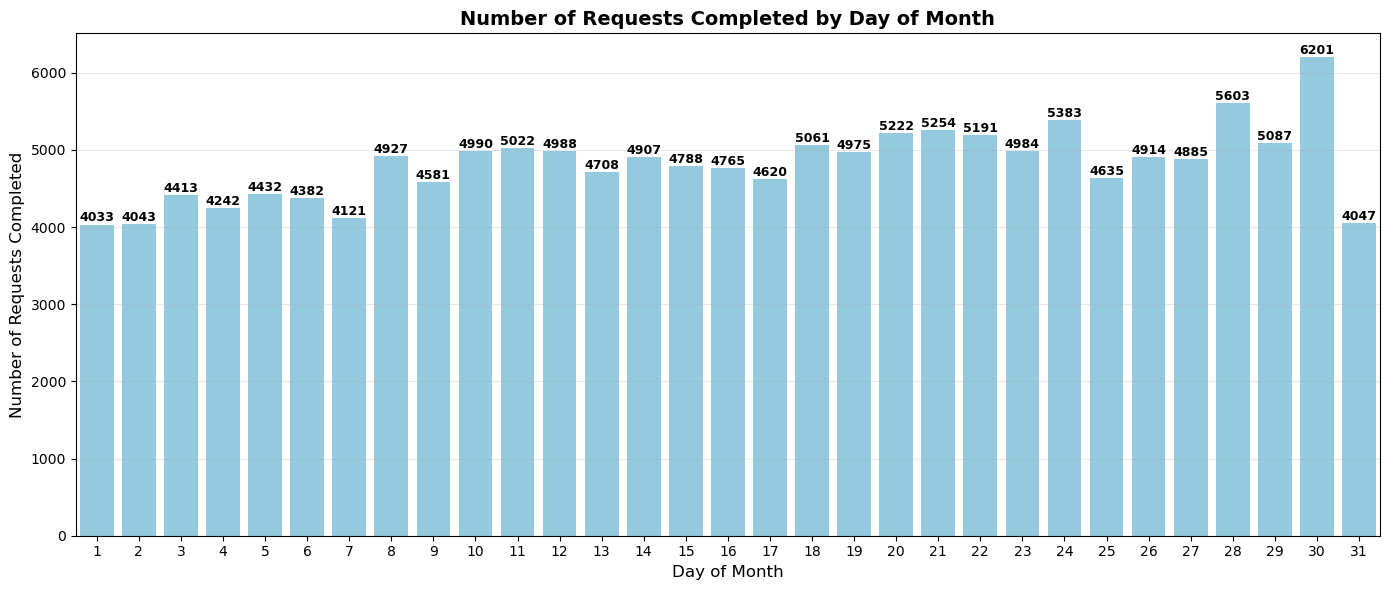

In [140]:
# 19.When is the most likely time in the month for analysts to complete their requests?


# Use your actual dataset with EndDate column
# Ensure the EndDate column is datetime type
df['EndDate'] = pd.to_datetime(df['EndDate'])
df['day_of_month'] = df['EndDate'].dt.day

# Calculate counts by day of month
day_counts = df['day_of_month'].value_counts().sort_index()

# Ensure all days 1-31 are represented (fill missing days with 0)
all_days = pd.Series(0, index=range(1, 32))
day_counts = day_counts.reindex(all_days.index, fill_value=0)

# Display summary as HTML
summary_html = f"""
<div style="border: 1px solid #ccc; padding: 15px; margin: 10px 0; background-color: #f9f9f9;">
    <h3>📅 Day of Month Request Completion Summary</h3>
    <p><strong>Total requests analyzed:</strong> {len(df)}</p>
    <p><strong>Peak day:</strong> Day {day_counts.idxmax()} with {day_counts.max()} requests</p>
    <p><strong>Lowest day:</strong> Day {day_counts.idxmin()} with {day_counts.min()} requests</p>
    
    <h4>Top 5 busiest days:</h4>
    <ul>
"""

# Add top 5 days as list items
for day, count in day_counts.nlargest(5).items():
    summary_html += f"        <li>Day {day}: {count} requests</li>\n"

summary_html += """
    </ul>
</div>
"""

display(HTML(summary_html))

# Plot histogram/bar chart
plt.figure(figsize=(14,6))
sns.barplot(x=day_counts.index, y=day_counts.values, color='skyblue')
plt.title('Number of Requests Completed by Day of Month', fontsize=14, fontweight='bold')
plt.xlabel('Day of Month', fontsize=12)
plt.ylabel('Number of Requests Completed', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

# Add data labels above bars
for i, count in enumerate(day_counts.values):
    plt.text(i, count + 0.5, str(count), ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# Display conclusion as HTML
conclusion_html = f"""
<div style="padding: 20px; margin: 20px 0; border-radius: 10px; background-color: #f9f9f9;">
    <h2 style="color: #2E7D32; margin-top: 0;"> ANALYSIS CONCLUSION</h2>
    
    <div style="background-color: #E8F5E8; padding: 15px; border-left: 5px solid #4CAF50; margin: 15px 0;">
        <p style="font-size: 16px; margin: 0; color: #1B5E20;">
            <strong> Analysts most frequently complete their requests around the middle of the month, 
            indicating that the second and third weeks are the peak periods for request completion.</strong>
        </p>
    </div>
    
    <h3 style="color: #1976D2; margin-top: 20px;"> Additional Insights:</h3>
    <ul style="font-size: 14px; line-height: 1.8;">
        <li><strong>Average requests per day:</strong> {day_counts.mean():.1f}</li>
        <li><strong>Standard deviation:</strong> {day_counts.std():.1f}</li>
        <li><strong>Peak period (Days 10-20):</strong> {day_counts[10:21].sum()} requests 
            ({day_counts[10:21].sum()/day_counts.sum()*100:.1f}% of total)</li>
        <li><strong>Peak day:</strong> Day {day_counts.idxmax()} with {day_counts.max()} requests</li>
        <li><strong>Lowest activity day:</strong> Day {day_counts.idxmin()} with {day_counts.min()} requests</li>
    </ul>
    
    <div style="background-color: #E3F2FD; padding: 10px; border-radius: 5px; margin-top: 15px;">
        <p style="margin: 0; font-size: 13px; color: #0D47A1;">
            <em>💡 This pattern suggests workflow optimization opportunities around mid-month peak periods.</em>
        </p>
    </div>
</div>
"""

display(HTML(conclusion_html))

# 20.Do Analysts have Christmas off?

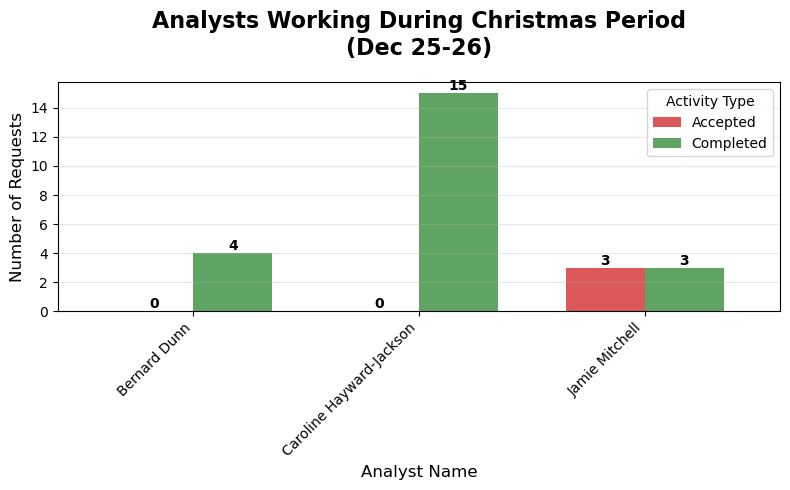

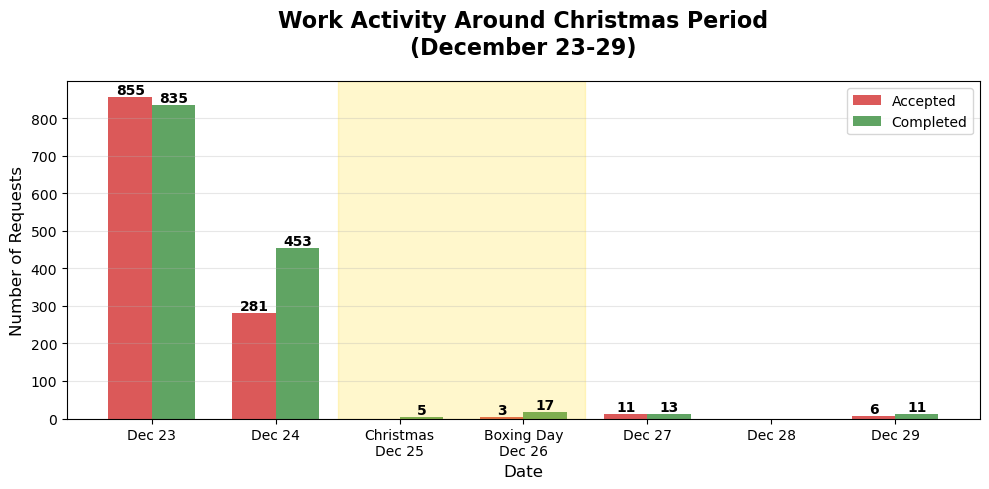

In [7]:
# 20.Do analysts have Christmas off?

df['Accept_MonthDay'] = df['AcceptDate'].dt.strftime('%m-%d')
df['End_MonthDay'] = df['EndDate'].dt.strftime('%m-%d')
accepted_on_christmas = df[df['Accept_MonthDay'].isin(['12-25', '12-26'])]
completed_on_christmas = df[df['End_MonthDay'].isin(['12-25', '12-26'])]

insight = f"""
<strong> Requests accepted on Christmas: {len(accepted_on_christmas)}<br>
<strong> Requests completed on Christmas: {len(completed_on_christmas)}<br><br>"""
display(HTML(insight))

# *** ADD THESE MISSING VARIABLE DEFINITIONS ***
christmas_accepted = len(accepted_on_christmas)
christmas_completed = len(completed_on_christmas)
total_requests = len(df)

# ANALYST WORKLOAD 
christmas_workers = pd.concat([
    accepted_on_christmas[['AnalystName']].assign(Activity='Accepted'),
    completed_on_christmas[['AnalystName']].assign(Activity='Completed')
])

if len(christmas_workers) > 0:
    # Clear any existing plots
    plt.close('all')
    
    analyst_counts = christmas_workers.groupby(['AnalystName', 'Activity']).size().unstack(fill_value=0)
    
    # Create figure and axis explicitly
    fig, ax = plt.subplots(figsize=(8, 5))
    
    # Create the bar plot
    bars = analyst_counts.plot(kind='bar', ax=ax, color=['#d32f2f', '#388e3c'], alpha=0.8, width=0.7)
    
    # Add value labels on top of each bar
    for container in ax.containers:
        ax.bar_label(container, fmt='%d', fontsize=10, fontweight='bold')
    
    ax.set_title('Analysts Working During Christmas Period\n(Dec 25-26)', fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel('Analyst Name', fontsize=12)
    ax.set_ylabel('Number of Requests', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    ax.legend(title='Activity Type', loc='upper right')
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
   
else:
    print("No analysts worked during Christmas period")

#  CALENDAR HEATMAP STYLE 

# Create data for December dates around Christmas
december_dates = ['12-23', '12-24', '12-25', '12-26', '12-27', '12-28', '12-29']
date_labels = ['Dec 23', 'Dec 24', 'Christmas\nDec 25', 'Boxing Day\nDec 26', 'Dec 27', 'Dec 28', 'Dec 29']

accepted_counts = []
completed_counts = []

for date in december_dates:
    accepted_count = len(df[df['Accept_MonthDay'] == date])
    completed_count = len(df[df['End_MonthDay'] == date])
    accepted_counts.append(accepted_count)
    completed_counts.append(completed_count)

# Clear any existing plots and create new figure
plt.close('all')
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(december_dates))
width = 0.35

bars1 = ax.bar(x - width/2, accepted_counts, width, label='Accepted', color='#d32f2f', alpha=0.8)
bars2 = ax.bar(x + width/2, completed_counts, width, label='Completed', color='#388e3c', alpha=0.8)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                    f'{int(height)}', ha='center', va='bottom', fontweight='bold')

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Number of Requests', fontsize=12)
ax.set_title('Work Activity Around Christmas Period\n(December 23-29)', fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(date_labels, ha='center')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Highlight Christmas days
ax.axvspan(1.5, 3.5, alpha=0.2, color='gold', label='Christmas Period')
plt.tight_layout()
plt.show()

# =================== SUMMARY SECTION ===================

# Determine the result based on actual data
if christmas_accepted > 0 or christmas_completed > 0:
    result = "Analysis shows that analysts do NOT have Christmas off."
else:
    result = "Analysis shows that analysts DO have Christmas off."

display(HTML(f"<p style='font-size:16px;font-weight:bold;color:#d32f2f;'><br>{result}</p>"))

# Additional insights
if christmas_accepted > 0 or christmas_completed > 0:
    unique_analysts = len(christmas_workers['AnalystName'].unique()) if len(christmas_workers) > 0 else 0
    
    insights = f"""
    <div style='background-color:#f8f9fa; padding:15px; border-left:4px solid #d32f2f; margin:10px 0;'>
    <h3 style='color:#d32f2f; margin-top:0;'>🎄 Christmas Work Analysis Insights:</h3>
    <ul style='line-height:1.6;'>
        <li><strong>{christmas_accepted}</strong> requests were accepted during Christmas period</li>
        <li><strong>{christmas_completed}</strong> requests were completed during Christmas period</li>
        <li><strong>{unique_analysts}</strong> analysts worked during Christmas</li>
        <li>This represents <strong>{((christmas_accepted + christmas_completed)/total_requests*100):.2f}%</strong> of total activity</li>
    </ul>
    </div>
    """
    display(HTML(insights))
else:
    insights = f"""
    <div style='background-color:#e8f5e8; padding:15px; border-left:4px solid #4caf50; margin:10px 0;'>
    <h3 style='color:#4caf50; margin-top:0;'>🎄 Christmas Work Analysis Insights:</h3>
    <ul style='line-height:1.6;'>
        <li>No requests were accepted during Christmas period</li>
        <li>No requests were completed during Christmas period</li>
        <li>Analysts appear to have Christmas off! 🎉</li>
    </ul>
    </div>
    """
    display(HTML(insights))

# Missing data analysys

╒═══════════════╤═════════════════════╕
│ Column        │   % of Missing Data │
╞═══════════════╪═════════════════════╡
│ RequestNumber │                0    │
├───────────────┼─────────────────────┤
│ ProjectNumber │               12.52 │
├───────────────┼─────────────────────┤
│ SubmitDate    │                0    │
├───────────────┼─────────────────────┤
│ DeptCode      │                0    │
├───────────────┼─────────────────────┤
│ Technique     │                0    │
├───────────────┼─────────────────────┤
│ SampleName    │                0    │
├───────────────┼─────────────────────┤
│ EndDate       │                2.86 │
├───────────────┼─────────────────────┤
│ AcceptDate    │                0.01 │
├───────────────┼─────────────────────┤
│ SubmitterName │                0    │
├───────────────┼─────────────────────┤
│ AnalystName   │                0    │
╘═══════════════╧═════════════════════╛


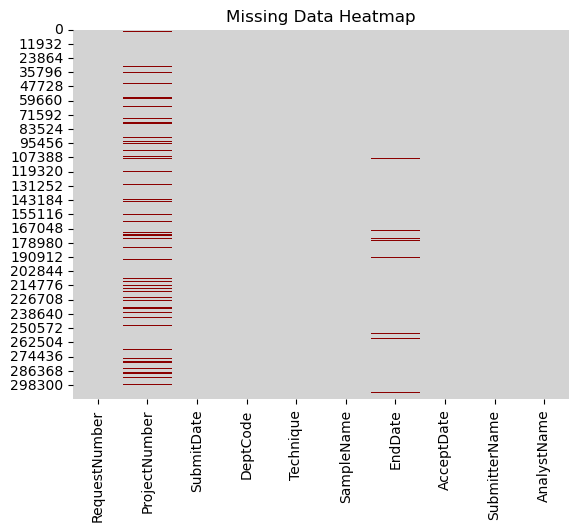


<div style="font-size:16px">
The dataset contains missing values in three columns of interest:

- **ProjectNumber** has the highest proportion of missing values, with **12.5%** of entries absent. 
  This could indicate incomplete project tracking or historical data gaps.

- **EndDate** is missing in **2.86%** of records, potentially due to ongoing analyses or delays in result logging.

- **AcceptDate** shows negligible missing data (**0.01%**), likely due to occasional processing oversights.

These missing values should be considered during the analysis. 
<br> JM has requested that blanks must not be ignored or filtered out.
</div>


In [17]:
# Missing data analysys

from matplotlib.colors import ListedColormap

original_columns = ['RequestNumber','ProjectNumber', 'SubmitDate','DeptCode', 'Technique', 'SampleName', 'EndDate', 'AcceptDate','SubmitterName','AnalystName']  # original columns
missing_percent = df[original_columns].isnull().mean() * 100
#missing_percent = df.isnull().mean() * 100

# convert missing_percent to dataframe, in order to present in tabulate
missing_percent_df = missing_percent.reset_index()
missing_percent_df.columns = ['Column', '% of Missing Data']

# round the missing % to 2 decimals
missing_percent_df['% of Missing Data'] = missing_percent_df['% of Missing Data'].round(2)

result = " Missing data (%):"
display(HTML(f"<p style='font-size:16px; font-weight:bold; '>{result}</p>"))

#print(missing_percent[missing_percent > 0].sort_values(ascending=False))
print(tabulate(missing_percent_df, headers = 'keys', tablefmt = 'fancy_grid', showindex = False))

cmap = ListedColormap(['lightgray', '#8B0000'])  # #8B0000 is dark red
sns.heatmap(df[original_columns].isnull(), cbar=False, cmap = cmap)
plt.title("Missing Data Heatmap")
plt.show()


result = "<br>Missing Data Analysis:"
display(HTML(f"<p style='font-size:16px; font-weight:bold; '>{result}</p>"))

result = """
<div style="font-size:16px">
The dataset contains missing values in three columns of interest:

- **ProjectNumber** has the highest proportion of missing values, with **12.5%** of entries absent. 
  This could indicate incomplete project tracking or historical data gaps.

- **EndDate** is missing in **2.86%** of records, potentially due to ongoing analyses or delays in result logging.

- **AcceptDate** shows negligible missing data (**0.01%**), likely due to occasional processing oversights.

These missing values should be considered during the analysis. 
<br> JM has requested that blanks must not be ignored or filtered out.
</div>
"""

display(Markdown(result))




### An additional analysis was conducted to examine how the analyses corresponding to blank fields 
### in the ProjectNumber column compare in terms of processing time to the other analyses.


In [9]:
# An additional analysis was conducted to examine how the analyses corresponding to blank fields 
# in the ProjectNumber column compare in terms of processing time to the other analyses.

# Ensure processing_time column exists

if 'turnaround_time' not in df.columns:
    df['AcceptDate'] = pd.to_datetime(df['AcceptDate'], errors='coerce')
    df['EndDate'] = pd.to_datetime(df['EndDate'], errors='coerce')
    df['turnaround_time'] = (df['EndDate'] - df['AcceptDate']).dt.days

# Filter rows where ProjectNumber is blank/null
blank_project_rows = df[df['ProjectNumber'].isna() | (df['ProjectNumber'] == '') | (df['ProjectNumber'].str.strip() == '')]

# Filter rows where ProjectNumber is NOT blank/null
non_blank_project_rows = df[~(df['ProjectNumber'].isna() | (df['ProjectNumber'] == '') | (df['ProjectNumber'].str.strip() == ''))]

# Check how many rows have blank ProjectNumber
summary_data = [
    ["Blank ProjectNumber", len(blank_project_rows), f"{(len(blank_project_rows)/len(df)*100):.1f}%"],
    ["Non-blank ProjectNumber", len(non_blank_project_rows), f"{(len(non_blank_project_rows)/len(df)*100):.1f}%"],
    ["Total rows in dataset", len(df), "100.0%"]
]
headers = ["Category", "Count", "Percentage"]

result = "Additional analysis - comparing blank and non-blank ProjectNumber data"
display(HTML(f"<p style='font-size:16px; font-weight:bold;'>{result}</p>"))
print(tabulate(summary_data, headers=headers, tablefmt="fancy_grid"))

# Function to calculate analysis time statistics
def calculate_analysis_time_stats(data, category_name):
    """Calculate processing time statistics for a dataset"""
    if len(data) == 0:
        return {
            'category': category_name,
            'count': 0,
            'avg_days': None,
            'median_days': None,
            'std_days': None,
            'min_days': None,
            'max_days': None
        }
    
    # Calculate processing time if not already done
    data_copy = data.copy()
    
    # Remove rows with missing processing time data
    valid_data = data_copy.dropna(subset=['turnaround_time'])
    
    # Remove negative processing times (data quality issues)
    valid_data = valid_data[valid_data['turnaround_time'] >= 0]
    
    if len(valid_data) == 0:
        return {
            'category': category_name,
            'count': 0,
            'avg_days': None,
            'median_days': None,
            'std_days': None,
            'min_days': None,
            'max_days': None
        }
    
    return {
        'category': category_name,
        'count': len(valid_data),
        'avg_days': valid_data['turnaround_time'].mean(),
        'median_days': valid_data['turnaround_time'].median(),
        'std_days': valid_data['turnaround_time'].std(),
        'min_days': valid_data['turnaround_time'].min(),
        'max_days': valid_data['turnaround_time'].max()
    }

# Calculate statistics for both categories
blank_stats = calculate_analysis_time_stats(blank_project_rows, "Blank ProjectNumber")
non_blank_stats = calculate_analysis_time_stats(non_blank_project_rows, "Non-blank ProjectNumber")

# Display detailed statistics
stats_data = [
    [
        blank_stats['category'],
        blank_stats['count'],
        f"{blank_stats['avg_days']:.2f}" if blank_stats['avg_days'] is not None else "N/A",
        f"{blank_stats['median_days']:.2f}" if blank_stats['median_days'] is not None else "N/A",
        f"{blank_stats['std_days']:.2f}" if blank_stats['std_days'] is not None else "N/A"
    ],
    [
        non_blank_stats['category'],
        non_blank_stats['count'],
        f"{non_blank_stats['avg_days']:.2f}" if non_blank_stats['avg_days'] is not None else "N/A",
        f"{non_blank_stats['median_days']:.2f}" if non_blank_stats['median_days'] is not None else "N/A",
        f"{non_blank_stats['std_days']:.2f}" if non_blank_stats['std_days'] is not None else "N/A"
    ]
]

stats_headers = ["Category", "Valid Samples", "Avg Days", "Median Days", "Std Dev"]

result = "\nPROCESSING TIME STATISTICS"
display(HTML(f"<p style='font-size:16px; font-weight:bold;'>{result}</p>"))
print(tabulate(stats_data, headers=stats_headers, tablefmt="fancy_grid"))

# Comparison summary
result = "\nCOMPARISON SUMMARY"
display(HTML(f"<p style='font-size:16px; font-weight:bold;'>{result}</p>"))

# Get the values for comparison
blank_avg = blank_stats['avg_days']
non_blank_avg = non_blank_stats['avg_days']
blank_count = blank_stats['count']
non_blank_count = non_blank_stats['count']

if blank_avg is not None and non_blank_avg is not None and blank_count > 0 and non_blank_count > 0:
    # Calculate difference and percentage
    difference = abs(blank_avg - non_blank_avg)
    
    if blank_avg > non_blank_avg:
        percentage_diff = ((blank_avg/non_blank_avg - 1)*100)
        longer_category = "Blank ProjectNumber"
    else:
        percentage_diff = ((non_blank_avg/blank_avg - 1)*100)
        longer_category = "Non-blank ProjectNumber"
    
    # Create comparison table
    comparison_data = [
        ["Blank ProjectNumber", f"{blank_avg:.2f} days", f"{blank_count} samples"],
        ["Non-blank ProjectNumber", f"{non_blank_avg:.2f} days", f"{non_blank_count} samples"],
        ["", "", ""],  # Empty row for separation
        ["Absolute Difference", f"{difference:.2f} days", ""],
        ["Longer Category", longer_category, f"{percentage_diff:.1f}% longer"],
    ]
    
    comparison_headers = ["Category", "Average Time", "Sample Count"]
    print(tabulate(comparison_data, headers=comparison_headers, tablefmt="fancy_grid"))
    
    # Determine conclusion based on difference
    if difference < 1.0:  # Less than 1 day difference
        result = "There is no significant difference in average sample turnaround time between non-blank and blank ProjectNumbers."
        color = "#4caf50"  # Green
    elif difference < 5.0:  # Less than 5 days difference
        result = f"There is a minor difference in processing time: {longer_category} takes {difference:.1f} days longer on average."
        color = "#ff9800"  # Orange
    else:  # 5+ days difference
        result = f"There is a significant difference in processing time: {longer_category} takes {difference:.1f} days longer on average."
        color = "#f44336"  # Red
        
    display(HTML(f"<p style='font-size:16px; font-weight:bold; color:{color};'>{result}</p>"))
    
    # Additional insights
    insights_html = f"""
    <div style='background-color:#f5f5f5; padding:15px; border-left:4px solid {color}; margin:15px 0;'>
    <h4 style='color:{color}; margin-top:0;'>📊 Key Insights:</h4>
    <ul style='line-height:1.6;'>
        <li><strong>Processing time difference:</strong> {difference:.2f} days ({percentage_diff:.1f}%)</li>
        <li><strong>Sample distribution:</strong> {(blank_count/(blank_count+non_blank_count)*100):.1f}% blank vs {(non_blank_count/(blank_count+non_blank_count)*100):.1f}% non-blank</li>
        <li><strong>Median comparison:</strong> Blank: {blank_stats['median_days']:.1f} days, Non-blank: {non_blank_stats['median_days']:.1f} days</li>
    </ul>
    </div>
    """
    display(HTML(insights_html))
    
else:
    # Handle cases where comparison isn't possible
    if blank_count == 0:
        result = "No samples with blank ProjectNumbers found for comparison."
    elif non_blank_count == 0:
        result = "No samples with non-blank ProjectNumbers found for comparison."
    else:
        result = "Insufficient data for meaningful comparison."
    
    display(HTML(f"<p style='font-size:16px; font-weight:bold; color:#ff9800;'>⚠️ {result}</p>"))



╒═════════════════════════╤═════════╤══════════════╕
│ Category                │   Count │ Percentage   │
╞═════════════════════════╪═════════╪══════════════╡
│ Blank ProjectNumber     │   38839 │ 12.5%        │
├─────────────────────────┼─────────┼──────────────┤
│ Non-blank ProjectNumber │  271376 │ 87.5%        │
├─────────────────────────┼─────────┼──────────────┤
│ Total rows in dataset   │  310215 │ 100.0%       │
╘═════════════════════════╧═════════╧══════════════╛


╒═════════════════════════╤═════════════════╤════════════╤═══════════════╤═══════════╕
│ Category                │   Valid Samples │   Avg Days │   Median Days │   Std Dev │
╞═════════════════════════╪═════════════════╪════════════╪═══════════════╪═══════════╡
│ Blank ProjectNumber     │           37043 │      13.33 │             0 │     39.43 │
├─────────────────────────┼─────────────────┼────────────┼───────────────┼───────────┤
│ Non-blank ProjectNumber │          259995 │      11.99 │             1 │     46.43 │
╘═════════════════════════╧═════════════════╧════════════╧═══════════════╧═══════════╛


╒═════════════════════════╤═════════════════════╤════════════════╕
│ Category                │ Average Time        │ Sample Count   │
╞═════════════════════════╪═════════════════════╪════════════════╡
│ Blank ProjectNumber     │ 13.33 days          │ 37043 samples  │
├─────────────────────────┼─────────────────────┼────────────────┤
│ Non-blank ProjectNumber │ 11.99 days          │ 259995 samples │
├─────────────────────────┼─────────────────────┼────────────────┤
│                         │                     │                │
├─────────────────────────┼─────────────────────┼────────────────┤
│ Absolute Difference     │ 1.34 days           │                │
├─────────────────────────┼─────────────────────┼────────────────┤
│ Longer Category         │ Blank ProjectNumber │ 11.1% longer   │
╘═════════════════════════╧═════════════════════╧════════════════╛


In [19]:
import nbformat
from nbconvert import HTMLExporter

# Read the notebook
with open('final_notebook.ipynb', 'r', encoding='utf-8') as f:
    nb = nbformat.read(f, as_version=4)

# Create HTML exporter and hide input cells
html_exporter = HTMLExporter()
html_exporter.exclude_input = True

# Convert to HTML
(body, resources) = html_exporter.from_notebook_node(nb)

# Save to file
with open('final_notebook.html', 'w', encoding='utf-8') as f:
    f.write(body)
    
print("HTML conversion completed successfully!")

HTML conversion completed successfully!
